# Introduction  

The **CICIDS2017 dataset** developed by the Canadian Institute for Cybersecurity (CIC) at the University of New Brunswick (UNB), is a widely recognized benchmark for evaluating modern intrusion detection systems. It consists of five days of realistic network traffic that includes both benign activities and fifteen distinct attack categories, such as DDoS, Brute Force, and Infiltration. The dataset features over 80 network flow attributes extracted using the CICFlowMeter tool, providing the comprehensive data necessary for training deep learning models to perform high-speed, real-time threat analysis. 

### Objectives of This Notebook:
1. **Data Cleaning**:
   - Handle missing values through removal or imputation.  
   - Eliminate duplicates and correct inconsistencies to maintain data quality.  

2. **Exploratory Data Analysis (EDA)**:  
   - Visualize and analyze the dataset to identify patterns, outliers, and correlations.  

3. **Feature Importance Evaluation**:
   - Evaluate feature importance with statistical tests and Random Forest.

4. **Dataset Preparation for Modeling**:  
   - Save a **cleaned dataset** for baseline model training.  

In [273]:
# Importing the relevant libraries

import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import sys

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.preprocessing import RobustScaler, QuantileTransformer, StandardScaler, PowerTransformer
from sklearn.utils import class_weight
from imblearn.over_sampling import SMOTE

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import tensorflow as tf
from keras import Sequential, Input
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Flatten, LSTM, GRU, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

import json

# Helper Functions

Section to organize some useful functions to further explore and work on the dataset.

In [2]:
# 1. Get numerical and categorical features (df, target_col='Attack Type') -> numerical features; categorical features
def get_feature_types(df, target_col='Attack Type'):
    """
    Identify numeric and categorical features, if present, in the dataset.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing the dataset
    target_col : str, optional (default='Attack Type')
        Name of the target column to exclude from features

    Returns:
    --------
    tuple : (list, list)
        Two lists containing:
        - numeric_features: List of column names with numerical data
        - categorical_features: List of column names with categorical data

    Notes:
    ------
    - Numerical features are identified as columns containing numeric data types
    - Categorical features are identified as columns containing object data types
    - The target column is excluded from both feature lists if present
    """

    numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_features = df.select_dtypes(include=['object']).columns.tolist()

    # Remove target column if present
    if target_col in numeric_features:
        numeric_features.remove(target_col)
    if target_col in categorical_features:
        categorical_features.remove(target_col)

    return numeric_features, categorical_features

In [3]:
# 2. Correlation analysis (df, numeric_features) -> list of tuples with highly correlaed features
def correlation_analysis(df, numeric_features, threshold=0.85):
    """
    Analyze correlations between numerical features.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing the dataset
    numeric_features : list
        List of column names containing numerical features to analyze
    threshold : float
        Threshold for determining highly correlated features (default='0.85')

    Returns:
    --------
    list of tuples
        List of highly correlated feature pairs and their correlation values
        Each tuple contains (feature1, feature2, correlation_value)

    Notes:
    ------
    - Generates a correlation matrix heatmap
    - Identifies feature pairs with absolute correlation > 0.85
    - Only returns upper triangle of correlation matrix to avoid duplicates
    - The heatmap uses a diverging color scheme centered at 0
    """

    # Calculate correlation matrix
    corr_matrix = df[numeric_features].corr()

    # Plot correlation heatmap
    plt.figure(figsize=(20, 20))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidth = 0.5)
    plt.title('Feature Correlation Heatmap')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

    # Identify highly correlated features
    threshold = threshold
    high_corr = np.where(np.abs(corr_matrix) > threshold)
    high_corr = [(corr_matrix.index[x], corr_matrix.columns[y], corr_matrix.iloc[x, y])
                 for x, y in zip(*high_corr) if x != y and x < y]

    return high_corr

In [4]:
# 3. Variance analysis (df, numeric_features, target_col='Attack Type') – Levene -> dict with results
def analyze_variance_homogeneity(df, numeric_features, target_col='Attack Type'):
    """
    Analyze the homogeneity of variances using Levene's test.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing the dataset.
    numeric_features : list
        List of column names containing numerical features to analyze.
    target_col : str, optional (default='Attack Type')
        Name of the target column

    Returns:
    --------
    dict
        Dictionary containing the results of Levene's test for each feature.
    """

    results_levene = {}

    for feature in numeric_features:
        # Group data by y and filter out groups with zero values
        groups = [group[feature].dropna().values for name, group in df.groupby(target_col)
                  if not group[feature].dropna().empty]

        # Filter out groups that contain only zero values or have zero variance
        groups = [group for group in groups if len(group) > 0 and np.any(group != 0) and np.var(group) > 0]

        # Check if there are at least two groups with valid data
        if len(groups) < 2:
            print(f"Not enough valid groups to perform Levene's test for feature: {feature}")
            continue  # Skip this feature if not enough valid groups

        # Perform Levene's Test
        stat_levene, p_value_levene = stats.levene(*groups)
        results_levene[feature] = {'Statistic': stat_levene, 'p-value': p_value_levene}

    return results_levene

In [5]:
# 4. Feature importance analysis (df, numeric_features, target_col='Attack Type') – Kruskal-Wallis -> df with H-statistics and p-values
def analyze_feature_importance(df, numeric_features, target_col='Attack Type'):
    """
    Analyze feature importance using the Kruskal-Wallis test.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing the dataset
    numeric_features : list
        List of column names containing numerical features to analyze
    target_col : str, optional (default='Attack Type')
        Name of the target column

    Returns:
    --------
    pandas.DataFrame
        DataFrame containing H-statistics and p-values for each feature,
        sorted by H-statistic in descending order

    Notes:
    ------
    - Uses the Kruskal-Wallis test to assess feature importance
    - Higher H-statistic indicates stronger relationship with target variable
    - Generates bar plot of H-statistics for visual comparison
    - Features are sorted by importance in the visualization
    """

    h_scores = {}

    for feature in numeric_features:
        # Group data by y and perform the Kruskal-Wallis test
        groups = [group[feature].dropna().values for name, group in df.groupby(target_col)]
        h_stat, p_val = stats.kruskal(*groups)
        h_scores[feature] = {'H-statistic': h_stat, 'p-value': p_val}

    # Create a DataFrame from the results
    h_scores_df = pd.DataFrame.from_dict(h_scores, orient='index')
    h_scores_df = h_scores_df.sort_values('H-statistic', ascending=False)

    # Plotting H-statistics
    plt.figure(figsize=(18, 10))
    plt.bar(range(len(h_scores_df)), h_scores_df['H-statistic'], color='skyblue')
    plt.xticks(range(len(h_scores_df)), h_scores_df.index, rotation=90)
    # plt.title('Feature Importance based on H-statistic (Kruskal-Wallis Test)')
    plt.xlabel('Features')
    plt.ylabel('H-statistic')
    plt.tight_layout()
    plt.show()

    return h_scores_df

In [6]:
def analyze_feature_importance_rf(df, numeric_features, target_col='Attack Type', subset_size=100000):
    """
    Analyze feature importance using a Random Forest classifier on a balanced subset of the data.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing the dataset
    numeric_features : list
        List of column names containing numerical features to analyze
    target_col : str
        Column name of the target variable
    subset_size : int
        Total number of samples to use for training/testing (balanced across classes)

    Returns:
    --------
    feature_importance_df : pandas.DataFrame
        Features sorted by importance
    cm : ndarray
        Confusion matrix
    rf_labels : list
        Class labels
    cv_scores : ndarray
        Cross-validation scores
    """

    # 1. Balance the subset across classes
    grouped = df.groupby(target_col)
    n_classes = len(grouped)
    samples_per_class = subset_size // n_classes

    balanced_subset = grouped.apply(lambda x: x.sample(n=min(len(x), samples_per_class),
                                                      random_state=42)).reset_index(drop=True)

    print(f"Using balanced subset with {len(balanced_subset):,} samples "
          f"({samples_per_class} per class approx.)")

    # 2. Prepare data
    X = balanced_subset[numeric_features]
    y = balanced_subset[target_col]

    # 3. Train/test split (stratified to maintain balance)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    # 4. Define model hyperparameters
    rf = RandomForestClassifier(
        n_estimators=150,
        max_depth=30,
        random_state=42,
        n_jobs=-1
    )

    # 5. Train
    rf.fit(X_train, y_train)

    # 6. Cross-validation
    cv_scores = cross_val_score(rf, X_train, y_train, cv=5, n_jobs=-1)
    print(f'Cross-Validation Score: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')

    # 7. Predictions
    y_pred = rf.predict(X_test)

    # 8. Feature importances
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': numeric_features, 'Importance': importances})
    feature_importance_df = feature_importance_df.sort_values('Importance', ascending=False)

    # 9. Confusion matrix & classification report
    rf_labels = rf.classes_
    cm = confusion_matrix(y_test, y_pred)
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, target_names=rf_labels))

    # 10. Plot feature importance
    plt.figure(figsize=(18, 10))
    plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='orange')
    plt.title('Feature Importance (Balanced Subset)')
    plt.ylabel('Importance')
    plt.xlabel('Features')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    return feature_importance_df, cm, rf_labels, cv_scores

In [7]:
# 6. Calculation of the percentage of outliers for each feature (df) – IQR -> dict with outliers percentage
def calculate_outliers_percentage(df):
    """
    Calculate the percentage of outliers for each feature in the DataFrame using the IQR method.

    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing the dataset.

    Returns:
    --------
    dict
        Dictionary containing the percentage of outliers for each feature.

    Notes:
    ------
    - Uses the Interquartile Range (IQR) method to identify outliers.
    - Outliers are defined as values below Q1 - 1.5 * IQR or above Q3 + 1.5 * IQR.
    - The function returns a dictionary with feature names as keys and outlier percentages as values.
    """

    outlier_percentages = {}  # empty dictionary to store outlier percentages

    for column in df.columns:
        Q1 = df[column].quantile(0.25)  # first quartile (Q1) for the column
        Q3 = df[column].quantile(0.75)  # third quartile (Q3) for the column
        IQR = Q3 - Q1  # Interquartile Range (IQR)

        lower_bound = Q1 - 1.5 * IQR  # lower bound for outliers
        upper_bound = Q3 + 1.5 * IQR  # upper bound for outliers

        # Identify outliers in the column
        outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

        # Calculate the percentage of outliers for the column
        outlier_percentage = len(outliers) / len(df) * 100

        # Store the outlier percentage in the dictionary
        outlier_percentages[column] = outlier_percentage

    return outlier_percentages


# 1. Initial Exploration

The first step is to load the dataset and examine its basic properties, such as dimensions, data types, and missing values.

## 1.1. Loading the Dataset

In [210]:
# List to store DataFrames
dfs = []
filenames = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv"
]
# Load the datasets
for filename in filenames:
    dfs.append(pd.read_csv(filename))

In [13]:
# Data dimensions of each individual dataset
for i, data in enumerate(dfs, start=1):
    rows, cols = data.shape
    print(f'df{i} -> {rows} rows, {cols} columns')

df1 -> 529918 rows, 79 columns
df2 -> 445909 rows, 79 columns
df3 -> 692703 rows, 79 columns
df4 -> 170366 rows, 79 columns
df5 -> 288602 rows, 79 columns
df6 -> 286467 rows, 79 columns
df7 -> 225745 rows, 79 columns
df8 -> 191033 rows, 79 columns


## 1.2. Merging the DataFrames

As noted by Panigrahi and Borah (2018), a typical IDS should be able to handle different types of attacks. Since the CICIDS2017 dataset is divided into eight files containing various attack data, these files should be merged into a single cohesive unit.

In [297]:
# Concatenate all DataFrames into a single DataFrame
# data = pd.concat(dfs, axis=0, ignore_index=True)

files = {
    "Monday-WorkingHours.pcap_ISCX.csv": "Monday",
    "Tuesday-WorkingHours.pcap_ISCX.csv": "Tuesday",
    "Wednesday-workingHours.pcap_ISCX.csv": "Wednesday",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv": "Thursday_Morning",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv": "Thursday_Afternoon",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv": "Friday_Morning",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv": "Friday_Afternoon_PortScan",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv": "Friday_Afternoon_DDoS"
}

dfs = []

for file, day in files.items():
    df = pd.read_csv(file)
    df['day'] = day            # 👈 ده الـ time proxy
    df['source_file'] = file   # (اختياري بس ممتاز)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# Deleting DataFrames after merging
for df in dfs: del df

In [298]:
del dfs

In [302]:
data["source_file"].unique()

array(['Monday-WorkingHours.pcap_ISCX.csv',
       'Tuesday-WorkingHours.pcap_ISCX.csv',
       'Wednesday-workingHours.pcap_ISCX.csv',
       'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
       'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
       'Friday-WorkingHours-Morning.pcap_ISCX.csv',
       'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
       'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'], dtype=object)

## 1.3. Data Overview

In [16]:
# Display the first few rows
data.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,3000000.0,5.000000e+05,4.0,0.0,4,4,4,4.0,0.0,4,4,0,0.0,0.0,0,0,0,0,0,0,40,0,5.000000e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,12000000.0,2.000000e+06,1.0,0.0,1,1,1,1.0,0.0,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4000000.0,6.666667e+05,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,6.666667e+05,0.0,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [17]:
# Display 10 random rows
data.sample(n=10, random_state=42)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
746827,443,32046067,2,0,74,0,37,37,37.000000,0.000000,0,0,0.000000,0.000000,2.309176,0.062410,3.200000e+07,0.000000e+00,32000000,32000000,32000000,3.200000e+07,0.000000e+00,32000000,32000000,0,0.0,0.000000e+00,0,0,1,0,0,0,64,0,0.062410,0.000000,37,37,37.000000,0.000000,0.000000e+00,0,1,0,0,1,1,0,0,0,55.500000,37.000000,0.000000,64,0,0,0,0,0,0,2,74,0,0,65535,-1,1,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
946912,53,66073,4,4,176,428,44,44,44.000000,0.000000,107,107,107.000000,0.000000,9141.404204,121.078201,9.439000e+03,2.316343e+04,61865,4,65918,2.197267e+04,3.801361e+04,65867,4,4161,1387.0,2.318350e+03,4064,48,0,0,0,0,104,128,60.539101,60.539101,44,107,72.000000,33.203915,1.102500e+03,0,0,0,0,0,0,0,0,1,81.000000,44.000000,107.000000,104,0,0,0,0,0,0,4,176,4,428,-1,-1,3,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2216843,32771,13,1,1,2,6,2,2,2.000000,0.000000,6,6,6.000000,0.000000,615384.615400,153846.153800,1.300000e+01,0.000000e+00,13,13,0,0.000000e+00,0.000000e+00,0,0,0,0.0,0.000000e+00,0,0,0,0,0,0,24,20,76923.076920,76923.076920,2,6,3.333333,2.309401,5.333333e+00,0,0,0,1,0,0,0,0,1,5.000000,2.000000,6.000000,24,0,0,0,0,0,0,1,2,1,6,1024,0,0,24,0.0,0.0,0,0,0.0,0.0,0,0,PortScan
699389,53,47619,1,1,44,213,44,44,44.000000,0.000000,213,213,213.000000,0.000000,5397.005397,42.000042,4.761900e+04,0.000000e+00,47619,47619,0,0.000000e+00,0.000000e+00,0,0,0,0.0,0.000000e+00,0,0,0,0,0,0,32,32,21.000021,21.000021,44,213,100.333333,97.572195,9.520333e+03,0,0,0,0,0,0,0,0,1,150.500000,44.000000,213.000000,32,0,0,0,0,0,0,1,44,1,213,-1,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1170268,80,99329635,6,7,320,11595,302,0,53.333333,121.856746,4344,0,1656.428571,1760.597234,119.954131,0.130877,8.277470e+06,2.870000e+07,99300000,1,99300000,1.990000e+07,4.440000e+07,99300000,1,99300000,16600000.0,4.050000e+07,99300000,15,0,0,0,0,164,232,0.060405,0.070472,0,4344,851.500000,1460.903869,2.134240e+06,1,0,0,0,0,0,0,0,1,917.000000,53.333333,1656.428571,164,0,0,0,0,0,0,6,320,7,11595,0,235,3,20,13973.0,0.0,13973,13973,99300000.0,0.0,99300000,99300000,DoS Hulk
800686,443,305034,22,45,871,63051,389,0,39.590909,99.163482,2896,0,1401.133333,535.012302,209556.967400,219.647646,4.621727e+03,1.307632e+04,78629,1,305034,1.452543e+04,2.061240e+04,78629,1,227392,5168.0,1.806263e+04,108635,48,0,0,0,0,716,1448,72.123108,147.524538,0,2896,940.029412,783.121976,6.132800e+05,0,0,0,1,0,0,0,0,2,954.059701,39.590909,1401.133333,716,0,0,0,0,0,0,22,871,45,63051,65535,122,6,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1434488,58409,18702,2,1,280,6,274,6,140.000000,189.504617,6,6,6.000000,0.000000,15292.482090,160.410651,9.351000e+03,1.304471e+04,18575,127,18702,1.870200e+04,0.000000e+00,18702,18702,0,0.0,0.000000e+00,0,0,1,0,0,

In [18]:
# Get dataset dimensions
print(f"Dataset Dimensions: {data.shape}")

Dataset Dimensions: (2830743, 79)


In [19]:
# Display data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0    Destination Port             int64  
 1    Flow Duration                int64  
 2    Total Fwd Packets            int64  
 3    Total Backward Packets       int64  
 4   Total Length of Fwd Packets   int64  
 5    Total Length of Bwd Packets  int64  
 6    Fwd Packet Length Max        int64  
 7    Fwd Packet Length Min        int64  
 8    Fwd Packet Length Mean       float64
 9    Fwd Packet Length Std        float64
 10  Bwd Packet Length Max         int64  
 11   Bwd Packet Length Min        int64  
 12   Bwd Packet Length Mean       float64
 13   Bwd Packet Length Std        float64
 14  Flow Bytes/s                  float64
 15   Flow Packets/s               float64
 16   Flow IAT Mean                float64
 17   Flow IAT Std                 float64
 18   Flow IAT Max         

By checking the data types, it is safe to assume the dataset countains only metric features, considering 'Label' as 'y' (the only categorical column).

In [20]:
# Checking for missing values
missing_values = data.isna().sum()
missing_percentage = (missing_values / len(data)) * 100

# Printing columns with missing values
for column, count in missing_values.items():
    if count != 0:
        print(f"Column '{column}' has {count} missing values, which is {missing_percentage[column]:.2f}% of the total")

Column 'Flow Bytes/s' has 1358 missing values, which is 0.05% of the total


In [21]:
data.describe()

C:\Users\mf\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\mf\AppData\Local\Programs\Python\Python312\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.829385e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2830743.0,2.830743e+06,2830743.0,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0,2830743.0,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,8.708495e+02,4.104958e+01,3.059493e+02,3.353257e+02,inf,inf,1.298449e+06,2.919271e+06,9.182475e+06,1.623796e+05,1.448296e+07,2.610193e+06,3.266957e+06,9.042939e+06,1.021893e+06,9.893830e+06,1.805784e+06,1.485973e+06,4.684692e+06,9.672614e+05,4.644646e-02,0.0,1.112782e-04,0.0,-2.599739e+04,-2.273275e+03,6.386535e+04,6.995192e+03,1.643450e+01,9.504024e+02,1.719444e+02,2.949756e+02,4.861548e+05,3.537976e-02,4.644646e-02,2.423392e-04,2.980705e-01,3.158443e-01,9.482316e-02,1.112782e-04,2.433990e-04,6.835004e-01,1.919837e+02,5.820194e+01,3.059493e+02,-2.599739e+04,0.0,0.0,0.0,0.0,0.0,0.0,9.361160e+00,5.492919e+02,1.039377e+01,1.616230e+04,6.989837e+03,1.989433e+03,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,1.946367e+03,6.886260e+01,6.052568e+02,8.396932e+02,NaN,NaN,4.507944e+06,8.045870e+06,2.445954e+07,2.950282e+06,3.357581e+07,9.525722e+06,9.639055e+06,2.452916e+07,8.591436e+06,2.873661e+07,8.887197e+06,6.278469e+06,1.716095e+07,8.308983e+06,2.104500e-01,0.0,1.054826e-02,0.0,2.105286e+07,1.452209e+06,2.475371e+05,3.815170e+04,2.523772e+01,2.028229e+03,3.054915e+02,6.318001e+02,1.647490e+06,1.847378e-01,2.104500e-01,1.556536e-02,4.574107e-01,4.648513e-01,2.929706e-01,1.054826e-02,1.559935e-02,6.804920e-01,3.318603e+02,1.860912e+02,6.052568e+02,2.105286e+07,0.0,0.0,0.0,0.0,0.0,0.0,7.496728e+02,9.980070e+03,9.973883e+02,2.26305

The number of missing values may initially seem irrelevant; however, we can decide on the approach after further analysis.

# 2. Data Cleaning

In [22]:
data.columns

Index([' Destination Port', ' Flow Duration', ' Total Fwd Packets',
       ' Total Backward Packets', 'Total Length of Fwd Packets',
       ' Total Length of Bwd Packets', ' Fwd Packet Length Max',
       ' Fwd Packet Length Min', ' Fwd Packet Length Mean',
       ' Fwd Packet Length Std', 'Bwd Packet Length Max',
       ' Bwd Packet Length Min', ' Bwd Packet Length Mean',
       ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s',
       ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min',
       'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max',
       ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std',
       ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags',
       ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length',
       ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s',
       ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean',
       ' Packet Length Std', ' Packet Length Variance', '

In [303]:
# Removal of leading/trailing whitespace
col_names = {col: col.strip() for col in data.columns}
data.rename(columns = col_names, inplace = True)

## 2.1. Duplicates and Infinite

In [304]:
# Checking and counting duplicates
duplicates = data.duplicated()
duplicate_count = duplicates.sum()

# Output results
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 256479


Removing duplicates from a dataset is often considered safe and beneficial as it enhances data integrity, improves statistical accuracy, increases efficiency, and simplifies analysis.

In [25]:
data[duplicates]

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2,49188,1,2,0,12,0,6,6,6.0,0.000000,0,0,0.0,0.0,1.200000e+07,2.000000e+06,1.000000,0.000000,1,1,1,1.000000,0.000000,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.000000,0,0,0.0,0.0,1.200000e+07,2.000000e+06,1.000000,0.000000,1,1,1,1.000000,0.000000,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,329,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
6,49486,1,2,0,12,0,6,6,6.0,0.000000,0,0,0.0,0.0,1.200000e+07,2.000000e+06,1.000000,0.000000,1,1,1,1.000000,0.000000,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
7,49486,1,2,0,12,0,6,6,6.0,0.000000,0,0,0.0,0.0,1.200000e+07,2.000000e+06,1.000000,0.000000,1,1,1,1.000000,0.000000,1,1,0,0.0,0.0,0,0,0,0,0,0,40,0,2.000000e+06,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,1,0,0,0,9.000000,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,245,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
46,389,1,2,0,7,0,7,0,3.5,4.949747,0,0,0.0,0.0,7.000000e+06,2.000000e+06,1.000000,0.000000,1,1,1,1.000000,0.000000,1,1,0,0.0,0.0,0,0,1,0,0,0,64,0,2.000000e+06,0.000000,0,7,4.666667,4.041452,16.333333,0,1,0,0,1,0,0,0,0,7.000000,3.5,0.0,64,0,0,0,0,0,0,2,7,0,0,237,-1,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830718,137,22,13,0,650,0,50,50,50.0,0.000000,0,0,0.0,0.0,2.950000e+07,5.909091e+05,1.833333,1.696699,7,1,22,1.833333,1.696699,7,1,0,0.0,0.0,0,0,0,0,0,0,260,0,5.909091e+05,0.000000,50,50,50.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,53.846154,50.0,0.0,260,0,0,0,0,0,0,13,650,0,0,-1,-1,12,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830720,123,121,2,2,96,96,48,48,48.0,0.000000,48,48,48.0,0.0,1.586777e+06,3.305785e+04,40.333333,63.799164,114,3,4,4.000000,0.000000,4,4,3,3.0,0.0,3,3,0,0,0,0,40,40,1.652893e+04,16528.925620,48,48,48.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,1,60.000000,48.0,48.0,40,0,0,0,0,0,0,2,96,2,96,-1,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2830726,22,147,1,1,0,0,0,0,0.0,0.000000,0,0,0.0,0.0,0.000000e+00,1.360544e+04,147.000000,0.000000,147,147,0,0.000000,0.000000,0,0,0,0.0,0.0,0,0,0,0,0,0,32,32,6.802721e+03,6802.721088,0,0,0.000000,0.000000,0.00

In [305]:
# Removal of duplicates
data = data.drop_duplicates(keep='first')
del duplicates
data.shape

(2574264, 81)

The same can be done for columns

In [308]:
# Identify columns with identical data
identical_columns = {}
columns = data.columns
list_control = columns.copy().tolist()

# Compare each pair of columns
for col1 in columns:
    for col2 in columns:
        if col1 != col2:
            if data[col1].equals(data[col2]):
                if (col1 not in identical_columns) and (col1 in list_control):
                    identical_columns[col1] = [col2]
                    list_control.remove(col2)
                elif (col1 in identical_columns) and (col1 in list_control):
                    identical_columns[col1].append(col2)
                    list_control.remove(col2)

# Print the result
if identical_columns:
    print("Identical columns found:")
    for key, value in identical_columns.items():
        print(f"'{key}' is identical to {value}")
else: print("No identical columns found.")

No identical columns found.


In [310]:
data[["Total Fwd Packets", "Subflow Fwd Packets"]].head(10)

KeyError: "['Subflow Fwd Packets'] not in index"

In [309]:
# Removing the columns with duplicated values
for key, value in identical_columns.items():
    data.drop(columns=value, inplace=True)

In [30]:
print(data.columns)
data.shape

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count',
       'PSH Flag C

(2522362, 67)

In [222]:
# Checking for infinite values
num_columns = data.select_dtypes(include = np.number).columns
has_infinite = np.isinf(data[num_columns]).sum()
print(has_infinite[has_infinite > 0])

Series([], dtype: int64)


In [32]:
data[np.isinf(data[num_columns])]

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Bytes,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2830737,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2830738,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2830739,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2830740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Removing infinite values is typically safe and beneficial, as it enhances data integrity, ensures statistical accuracy, aids in proper model training, and clarifies insights.

In [307]:
# Treating infinite values
data.replace([np.inf, -np.inf], np.nan, inplace=True)

C:\Users\mf\AppData\Local\Temp\ipykernel_16484\3641657517.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.replace([np.inf, -np.inf], np.nan, inplace=True)


## 2.1. Missing Values

There are different approaches to dealing with missing values. The first step in identifying how to proceed is to understand their impact on the dataset. Here, we will do that by analyzing the y column (Label).

In [34]:
# Attack counts
attack_counts = data['Label'].value_counts().reset_index()
attack_counts.columns = ['Attack Type', 'Number of Occurrences']

# Duplicating the df and dropping rows with missing values
data_no_na = data.dropna()

# Counting the total number of occurrences of each attack after dropping
occurrences_nonull = data_no_na['Label'].value_counts().reset_index()
occurrences_nonull.columns = ['Attack Type', 'Occurrences w/o Null Rows']

# Merging the DataFrames
attack_counts = attack_counts.merge(occurrences_nonull, on='Attack Type', how='left')

# Calculating the difference
attack_counts['Abs Difference'] = attack_counts['Number of Occurrences'] - attack_counts['Occurrences w/o Null Rows']
attack_counts['Difference %'] = ((attack_counts['Abs Difference'] * 100) / attack_counts['Number of Occurrences']).round(2)

# Visualization
attack_counts

,Attack Type,Number of Occurrences,Occurrences w/o Null Rows,Abs Difference,Difference %
0,BENIGN,2096484,2095057,1427,0.07
1,DoS Hulk,172849,172846,3,0.00
2,DDoS,128016,128014,2,0.00
3,PortScan,90819,90694,125,0.14
4,DoS GoldenEye,10286,10286,0,0.00
5,FTP-Patator,5933,5931,2,0.03
6,DoS slowloris,5385,5385,0,0.00
7,DoS Slowhttptest,5228,5228,0,0.00
8,SSH-Patator,3219,3219,0,0.00
9,Bot,1953,1948,5,0.26


In [35]:
# Cleaning up
del data_no_na

# Evaluating percentage of missing values per column
threshold = 10
missing_percentage = (data.isnull().sum() / len(data)) * 100

# Filter columns with missing values over the threshold
high_missing_cols = missing_percentage[missing_percentage > threshold]

# Print columns with high missing percentages
if len(high_missing_cols) > 0:
    print(f'The following columns have over {threshold}% of missing values:')
    print(high_missing_cols)
else:
    print('There are no columns with missing values greater than the threshold')

There are no columns with missing values greater than the threshold


The analysis of missing values across the dataset suggests that missing values are not heavily concentrated in any single column and that the dataset can tolerate row-wise removal without significant impact.

In [36]:
row_missing_percentage = (data.isna().sum(axis=1) / data.shape[1]) * 100
print(row_missing_percentage.describe())

missing_rows = data.isna().any(axis=1).sum()
print(f'\nTotal rows with missing values: {missing_rows}')

count    2.522362e+06
mean     1.850907e-03
std      7.430795e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.985075e+00
dtype: float64

Total rows with missing values: 1564


Following previous studies, such as Panigrahi and Borah (2018), and considering the minimal impact of removing rows with missing values (concentrated on the Benign class), we will proceed to drop these rows from the DataFrame.

In [313]:
# Dropping missing values
data = data.dropna()
print(f'Dataset shape after row-wise removal: {data.shape}')

Dataset shape after row-wise removal: (2572640, 69)


In [195]:
np.inf in data["Flow Duration"]

False

## 2.2. Data-Driven Feature Selection

The idea here is to perform a straightforward manual feature selection process that focuses on examining the dataset critically.

In [316]:
# Check for numeric columns that contain only a single unique value, indicating no diversity in values.
# Such columns contribute no useful information to the analysis and may be candidates for removal.
only_unique_cols = []
for col in data.columns:
    if len(data[col].unique()) == 1:
        only_unique_cols.append(col)
        print(col)

print(f'\nThe number of columns with only one unique values is: {len(only_unique_cols)}')

Bwd PSH Flags

The number of columns with only one unique values is: 1


In [40]:
data["Bwd PSH Flags"]

0          0
1          0
4          0
5          0
8          0
          ..
2830737    0
2830738    0
2830739    0
2830740    0
2830742    0
Name: Bwd PSH Flags, Length: 2520798, dtype: int64


Columns with only a single unique value can typically be removed from the dataset before training machine learning models without risk of loss of relevant information.

In [317]:
# Dropping the columns with only one unique value
data.drop(only_unique_cols, axis=1, inplace=True)
del only_unique_cols

In [318]:
# Checking the new shape after cleaning
data.shape

(2572640, 68)

## 2.3 Avoiding Data Leakage

In [43]:
# Removing 'Destination Port' to prevent data leakage and overfitting. 
# We want the model to learn the behavioral patterns of attacks rather than memorizing static port numbers, 
# ensuring better generalization to new, unseen threats.
port_label_analysis = pd.crosstab(data['Destination Port'], data['Label'])

for column in port_label_analysis.columns:
    top_ports = port_label_analysis[column].sort_values(ascending=False).head(5)
    print(f"\nTop 5 Ports for Attack Type: {column}")
    print(top_ports)


Top 5 Ports for Attack Type: BENIGN
Destination Port
53     876783
443    470173
80     217956
123     21333
22       6868
Name: BENIGN, dtype: int64

Top 5 Ports for Attack Type: Bot
Destination Port
8080    1247
4077       1
3832       1
1857       1
1858       1
Name: Bot, dtype: int64

Top 5 Ports for Attack Type: DDoS
Destination Port
80       128011
27636         1
64869         1
64873         1
24            0
Name: DDoS, dtype: int64

Top 5 Ports for Attack Type: DoS GoldenEye
Destination Port
80       10286
22           0
23           0
24           0
65504        0
Name: DoS GoldenEye, dtype: int64

Top 5 Ports for Attack Type: DoS Hulk
Destination Port
80       172846
22            0
23            0
24            0
65504         0
Name: DoS Hulk, dtype: int64

Top 5 Ports for Attack Type: DoS Slowhttptest
Destination Port
80       5228
22          0
23          0
24          0
65504       0
Name: DoS Slowhttptest, dtype: int64

Top 5 Ports for Attack Type: DoS slowloris
De

In [319]:
data = data.drop(columns=["Destination Port"])

In [45]:
bias_check = data.groupby('Label')['Init_Win_bytes_forward'].agg(['mean', 'std', 'min', 'max', 'nunique'])

print("Analysis of 'Init_Win_bytes_forward' per Attack Type:")
print(bias_check)

unique_values_per_attack = data.groupby('Label')['Init_Win_bytes_forward'].value_counts(normalize=True).head(10)
print("\nTop value distributions (Potential Signatures):")
print(unique_values_per_attack)

Analysis of 'Init_Win_bytes_forward' per Attack Type:
                                    mean           std  min    max  nunique
Label                                                                      
BENIGN                       7284.138554  15178.414236   -1  65535    12142
Bot                          5370.660678   3946.006695  237  29200       29
DDoS                         3890.261956   4052.494249    0  29200        6
DoS GoldenEye               21014.922710  12999.550194  227  29200        6
DoS Hulk                     2613.523987   8070.578731    0  29200       15
DoS Slowhttptest            23592.118783  11447.230066  229  29200        5
DoS slowloris               21037.809471  13029.969105  229  29200        8
FTP-Patator                 19640.691789  13623.277348  227  29200        3
Heartbleed                   2899.272727   8723.120842  235  29200        3
Infiltration                 2111.166667   2995.491961  255   8192        5
PortScan                    15206.

In [320]:
# Dropping Init_Win_bytes features because they exhibit synthetic bias. 
# The very low nunique values per attack class (e.g., 3-6 unique values for thousands of samples) 
# indicate that the model would perform OS Fingerprinting instead of Intrusion Detection, leading to poor generalization in real-world scenarios.

data = data.drop(columns=["Init_Win_bytes_forward", "Init_Win_bytes_backward"])

In [47]:
data.columns

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'RST Flag Count',
       'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', '

In [48]:
import pandas as pd
import numpy as np

def find_dead_columns(df, threshold=0.99):
    dead_cols = []
    
    for col in df.columns:
        if col == 'Label': continue
        
        most_freq_value_ratio = df[col].value_counts(normalize=True).iloc[0]
        
        if most_freq_value_ratio >= threshold:
            dead_cols.append(col)
            
    return dead_cols

dead_features = find_dead_columns(data, threshold=0.99)

print(f"--- Found {len(dead_features)} Dead or Quasi-dead columns ---")
for col in dead_features:
    val = data[col].value_counts().index[0]
    percent = data[col].value_counts(normalize=True).iloc[0] * 100
    print(f"Column: {col:<25} | Dominant Value: {val:<5} | Frequency: {percent:.2f}%")

--- Found 3 Dead or Quasi-dead columns ---
Column: Fwd URG Flags             | Dominant Value: 0     | Frequency: 100.00%
Column: RST Flag Count            | Dominant Value: 0     | Frequency: 99.97%
Column: ECE Flag Count            | Dominant Value: 0     | Frequency: 99.97%


In [321]:
# Model doesn't learn or cheat from that column
data = data.drop(columns=["ECE Flag Count", "RST Flag Count"])

In [50]:
data.shape[1]

61

In [51]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# 1. Take a representative sample to speed up the process
data_sample = data.sample(n=50000, random_state=42)

# 2. Separate features and target
X_sample = data_sample.drop(columns=['Label'])
y_sample = data_sample['Label']

# 3. Calculate Mutual Information
# This measures the dependency between each feature and the target
mi_scores = mutual_info_classif(X_sample, y_sample)

# 4. Create a clean results table
mi_results = pd.Series(mi_scores, index=X_sample.columns).sort_values(ascending=False)

In [52]:
print("--- Mutual Information Scores ---")
print(mi_results.head(20))

--- Mutual Information Scores ---
Average Packet Size            0.533592
Packet Length Std              0.507223
Packet Length Variance         0.504939
Packet Length Mean             0.504928
Subflow Bwd Bytes              0.474854
Total Length of Bwd Packets    0.474308
Bwd Packet Length Mean         0.466719
Avg Bwd Segment Size           0.466344
Subflow Fwd Bytes              0.453299
Total Length of Fwd Packets    0.452402
Bwd Packet Length Max          0.435880
Max Packet Length              0.427761
Fwd Packet Length Max          0.422534
Fwd IAT Max                    0.398674
Flow IAT Max                   0.383404
Fwd Header Length              0.383153
Fwd IAT Total                  0.380477
Flow Duration                  0.363787
Fwd IAT Mean                   0.360180
Bwd Packet Length Std          0.359406
dtype: float64


In [53]:
mi_results.tail(15)

act_data_pkt_fwd         0.164588
Fwd IAT Min              0.161729
min_seg_size_forward     0.150670
Min Packet Length        0.147462
Fwd Packet Length Min    0.145173
Flow IAT Min             0.129186
PSH Flag Count           0.060947
Down/Up Ratio            0.053161
FIN Flag Count           0.046844
Idle Std                 0.037465
ACK Flag Count           0.031769
Active Std               0.018366
URG Flag Count           0.018062
Fwd PSH Flags            0.011866
Fwd URG Flags            0.000984
dtype: float64

In [322]:
data = data.drop(columns=["Fwd Header Length", "Bwd Header Length"])

## 2.4. Grouping/ Removing Attack Types

As seen previously, the dataset categorizes various types of attacks into distinct groups, including different variations of Denial of Service (DoS) attacks. Given the imbalance present in the dataset, consolidating these classes could enhance the training process of DL models. This approach allows models to learn from a more balanced representation of the data, potentially improving classification accuracy and model performance.

In [323]:
# # Mapping the attacks to the new group
# group_mapping = {
#     'BENIGN': 'Normal',
#     'DoS Hulk': 'Malicious',
#     'DDoS': 'Malicious',
#     'PortScan': 'Malicious',
#     'DoS GoldenEye': 'Malicious',
#     'FTP-Patator': 'Malicious',
#     'DoS slowloris': 'Malicious',
#     'DoS Slowhttptest': 'Malicious',
#     'SSH-Patator': 'Malicious',
#     'Bot': 'Malicious',
#     'Web Attack � Brute Force': 'Malicious',
#     'Web Attack � XSS': 'Malicious',
#     'Infiltration': 'Malicious',
#     'Web Attack � Sql Injection': 'Malicious',
#     'Heartbleed': 'Malicious'
# }

# Map to new group column
data['Attack Type'] = data['Label']

In [324]:
# Checking the new values
data['Attack Type'].value_counts()

Attack Type
BENIGN                        2146899
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [325]:
# Dropping the old 'Label' column
data.drop(columns='Label', inplace=True)

# 3. Exploratory Data Analysis (EDA)

## 3.1. Descriptive Statistics

In [58]:
data.sample(10)

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Bytes,Subflow Bwd Bytes,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Type
569602,161,2,2,58,90,29,29,29.000000,0.000000,45,45,45.000000,0.000000,9.192547e+05,24844.720500,5.366667e+01,5.272887e+01,109,4,4,4.0,0.000000e+00,4,4,48,4.800000e+01,0.000000e+00,48,48,0,0,12422.360250,12422.360250,29,45,35.400000,8.763561,7.680000e+01,0,0,0,0,1,44.250000,29.000000,45.000000,58,90,1,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1885716,2108426,61,70,2253,116642,534,0,36.934426,125.292041,4344,0,1666.314286,955.951041,5.639041e+04,62.131657,1.621866e+04,5.274958e+04,343868,0,1764558,29409.3,6.724059e+04,310810,0,2084619,3.021187e+04,7.202233e+04,343884,1,0,0,28.931535,33.200122,0,4344,900.719697,1074.873991,1.155354e+06,0,1,0,0,1,907.595420,36.934426,1666.314286,2253,116642,5,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2492222,10095610,1,6,6,36,6,6,6.000000,0.000000,6,6,6.000000,0.000000,4.160224e+00,0.693371,1.682602e+06,4.112581e+06,10100000,1,0,0.0,0.000000e+00,0,0,10100000,2.017548e+06,4.505578e+06,10100000,1,0,0,0.099053,0.594318,6,6,6.000000,0.000000,0.000000e+00,0,0,1,1,6,6.857143,6.000000,6.000000,6,36,0,20,18242.0,0.0,18242,18242,10100000.0,0.0,10100000,10100000,BENIGN
1347604,1593,2,0,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000e+00,1255.492781,1.593000e+03,0.000000e+00,1593,1593,1593,1593.0,0.000000e+00,1593,1593,0,0.000000e+00,0.000000e+00,0,0,0,0,1255.492781,0.000000,0,0,0.000000,0.000000,0.000000e+00,0,0,1,0,0,0.000000,0.000000,0.000000,0,0,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1115608,99511945,7,7,388,11595,382,0,55.428571,144.021824,4344,0,1656.428571,1757.579003,1.204177e+02,0.140687,7.654765e+06,2.760000e+07,99400000,1,99400000,16600000.0,4.060000e+07,99400000,1,145721,2.428683e+04,5.397495e+04,134094,47,0,0,0.070343,0.070343,0,4344,798.866667,1422.119488,2.022424e+06,0,0,1,0,1,855.928571,55.428571,1656.428571,388,11595,2,20,1981.0,0.0,1981,1981,99400000.0,0.0,99400000,99400000,DoS Hulk
1743796,192391,1,1,52,156,52,52,52.000000,0.000000,156,156,156.000000,0.000000,1.081132e+03,10.395497,1.923910e+05,0.000000e+00,192391,192391,0,0.0,0.000000e+00,0,0,0,0.000000e+00,0.000000e+00,0,0,0,0,5.197748,5.197748,52,156,86.666667,60.044428,3.605333e+03,0,0,0,0,1,130.000000,52.000000,156.000000,52,156,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1159435,97846699,7,6,365,11595,359,0,52.142857,135.329756,5792,0,1932.500000,2181.008184,1.222320e+02,0.132861,8.153892e+06,2.820000e+07,97800000,1,97800000,16300000.0,3.990000e+07,97800000,1,33430,6.686000e+03,9.840924e+03,22125,45,0,0,0.071540,0.061320,0,5792,854.285714,1666.479035,2.777152e+06,0,0,1,0,0,920.000000,52.142857,1932.500000,365,11595,2,20,5.0,0.0,5,5,97800000.0,0.0,97800000,97800000,DoS Hulk
2431045,61,1,1,0,0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.000000e+00,32786.885250,6.100000e+01,0.000000e+00,61,61,0,0.0,0.000000e+00,0,0,0,0.000000e+00,0.000000e+00,0,0,0,0,16393.442620,16393.442620,0,0,0.000000,0.000000,0.000000e+00,0,0,1,1,1,0.000000,0.000000,0.000000,0,0,0,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
370311,202,2,2,132,260,66,66,66.000000,0.000000,130,130,130.000000,0.000000,1.940594e+06,19801.980198,6.733333e+01,7.715137e+01,152,1

In [59]:
data.describe()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Fwd URG Flags,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Bytes,Subflow Bwd Bytes,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06,2.520798e+06
mean,1.659161e+07,1.028174e+01,1.157280e+01,6.119477e+02,1.814440e+04,2.312292e+02,1.920349e+01,6.350497e+01,7.732347e+01,9.749726e+02,4.315945e+01,3.406225e+02,3.765453e+02,1.410707e+06,4.729188e+04,1.446142e+06,3.278153e+06,1.029948e+07,1.704214e+05,1.625184e+07,2.919257e+06,3.668641e+06,1.014294e+07,1.135671e+06,1.111025e+07,2.027734e+06,1.668681e+06,5.260619e+06,1.086111e+06,4.866832e-02,3.173598e-05,4.085969e+04,6.513513e+03,1.683200e+01,1.063750e+03,1.906548e+02,3.302006e+02,5.457761e+05,3.209539e-02,2.976085e-01,3.118723e-01,1.013929e-01,7.004476e-01,2.124358e+02,6.350497e+01,3.406225e+02,6.119359e+02,1.814402e+04,6.009478e+00,-3.082233e+03,9.157847e+04,4.619177e+04,1.720171e+05,6.546359e+04,9.337367e+06,5.657941e+05,9.763770e+06,8.892671e+06
std,3.523276e+07,7.944201e+02,1.056922e+03,1.058827e+04,2.398177e+06,7.563755e+02,6.079834e+01,1.955526e+02,2.968814e+02,2.038347e+03,7.087972e+01,6.325636e+02,8.810547e+02,2.657084e+07,2.026366e+05,4.683197e+06,8.456754e+06,2.568537e+07,3.014304e+06,3.516638e+07,1.001639e+07,1.014208e+07,2.576650e+07,9.059498e+06,3.022924e+07,9.393386e+06,6.630315e+06,1.810168e+07,8.797215e+06,2.151737e-01,5.633382e-03,1.932655e+05,3.814460e+04,2.558415e+01,2.121693e+03,3.183562e+02,6.608889e+02,1.736478e+06,1.762535e-01,4.572065e-01,4.632581e-01,3.018483e-01,6.956600e-01,3.455032e+02,1.955526e+02,6.325636e+02,1.057394e+04,2.398145e+06,6.744150e+02,1.149758e+06,6.866503e+05,4.165844e+05,1.085571e+06,6.111585e+05,2.484818e+07,4.874169e+06,2.561746e+07,2.458143e+07
min,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.610000e+08,-2.000000e+06,-1.300000e+01,0.000000e+00,-1.300000e+01,-1.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.080000e+0

## 3.2 Investigating Negatives

In [161]:
numeric_df = data.select_dtypes(include=['number'])
negative_counts = (numeric_df < 0).sum()
negative_only = negative_counts[negative_counts > 0]
negative_only

Flow Duration          2
Total Fwd Packets    173
Flow Packets/s         2
Flow IAT Mean          2
Flow IAT Max           1
Fwd IAT Mean           2
dtype: int64

In [61]:
data["Flow Bytes/s"].describe()

count    2.520798e+06
mean     1.410707e+06
std      2.657084e+07
min     -2.610000e+08
25%      1.194308e+02
50%      3.715038e+03
75%      1.071429e+05
max      2.071000e+09
Name: Flow Bytes/s, dtype: float64

In [326]:
# Investigate negative values across all numerical features to determine if they are noise, placeholders, or attack signatures.
negative_columns_names = negative_only.index.tolist()

for col in negative_columns_names:
    print(f"Negative values in {col} : {data[data[col] < 0][col].unique()}")
    print(f"Attack types for these negative values: {data[data[col] < 0]['Attack Type'].unique()}")
    print("="*50)

Negative values in Flow Duration : [ -1  -4  -2 -12 -13]
Attack types for these negative values: ['BENIGN']
Negative values in Total Fwd Packets : []
Attack types for these negative values: []
Negative values in Flow Packets/s : [-2000000.      -500000.     -1000000.      -166666.6667  -153846.1538]
Attack types for these negative values: ['BENIGN']
Negative values in Flow IAT Mean : [ -1.  -4.  -2. -12. -13.]
Attack types for these negative values: ['BENIGN']
Negative values in Flow IAT Max : [ -1  -4  -2 -12 -13]
Attack types for these negative values: ['BENIGN']
Negative values in Fwd IAT Mean : []
Attack types for these negative values: []


In [327]:
data=data.drop(columns="min_seg_size_forward")

In [328]:
# 1. Identify numeric columns
numeric_cols = data.select_dtypes(include=[np.number]).columns

# 2. Count rows before cleaning
initial_rows = len(data)

# 3. Filter out any row that contains a negative value in any numeric column
# Note: Some features like 'Init_Win_bytes' might legitimately have -1 in some datasets, 
# but in CICIDS2017 timing and size columns, negative is ALWAYS an error.
data = data[(data[numeric_cols] >= 0).all(axis=1)]

# 4. Show how many rows were dropped
dropped_rows = initial_rows - len(data)
print(f"Dropped {dropped_rows} rows containing negative glitch values.")

Dropped 2887 rows containing negative glitch values.


## 3.3. Correlation Analysis

The correlation analysis provides valuable insights that could inform further data engineering efforts, such as considering the application of Principal Component Analysis (PCA) to reduce dimensionality and enhance model performance.

In [65]:
data.shape

(2517918, 58)

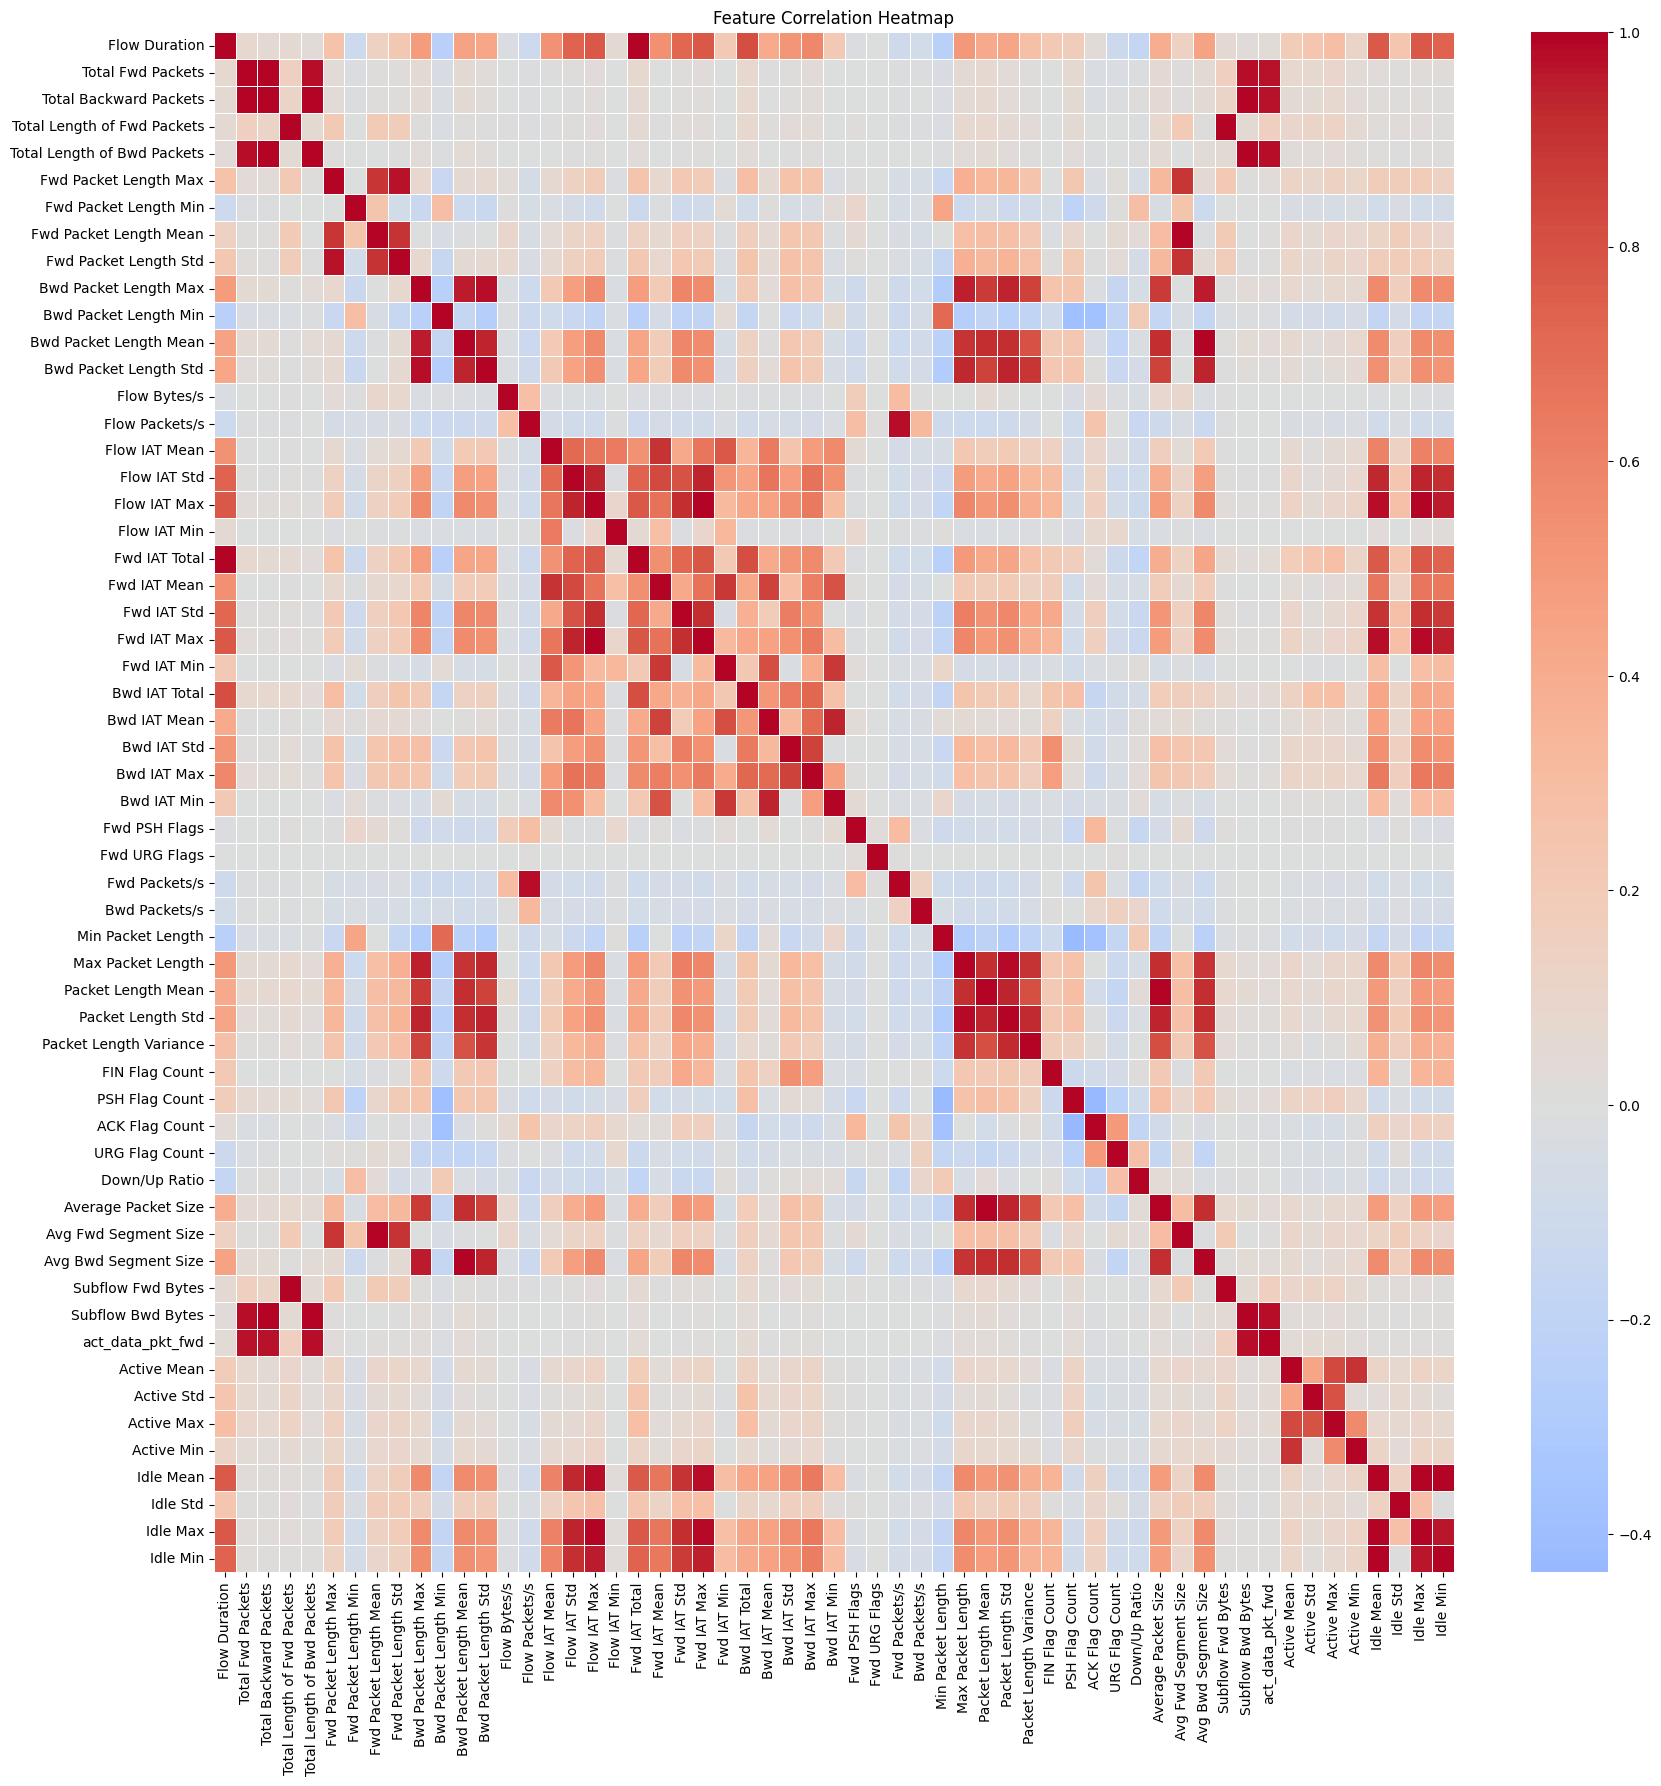

In [66]:
# Correlation Analysis:
numeric_features, categorical_features = get_feature_types(data)
high_corr = correlation_analysis(data, numeric_features)

In [67]:
# Printing the pairs with high correlation and isolating the near/perfect multicollinearity
high_multicollinearity = []
for item in high_corr:
    print(f'{item[0]} has a high correlation with {item[1]}: {item[2].round(4)}')
    if item[2] >= 0.95:
        high_multicollinearity.append(item)

Flow Duration has a high correlation with Fwd IAT Total: 0.9985
Total Fwd Packets has a high correlation with Total Backward Packets: 0.9916
Total Fwd Packets has a high correlation with Total Length of Bwd Packets: 0.9808
Total Fwd Packets has a high correlation with Subflow Bwd Bytes: 0.9807
Total Fwd Packets has a high correlation with act_data_pkt_fwd: 0.9673
Total Backward Packets has a high correlation with Total Length of Bwd Packets: 0.9898
Total Backward Packets has a high correlation with Subflow Bwd Bytes: 0.9898
Total Backward Packets has a high correlation with act_data_pkt_fwd: 0.9684
Total Length of Fwd Packets has a high correlation with Subflow Fwd Bytes: 1.0
Total Length of Bwd Packets has a high correlation with Subflow Bwd Bytes: 1.0
Total Length of Bwd Packets has a high correlation with act_data_pkt_fwd: 0.9727
Fwd Packet Length Max has a high correlation with Fwd Packet Length Mean: 0.8894
Fwd Packet Length Max has a high correlation with Fwd Packet Length Std: 0

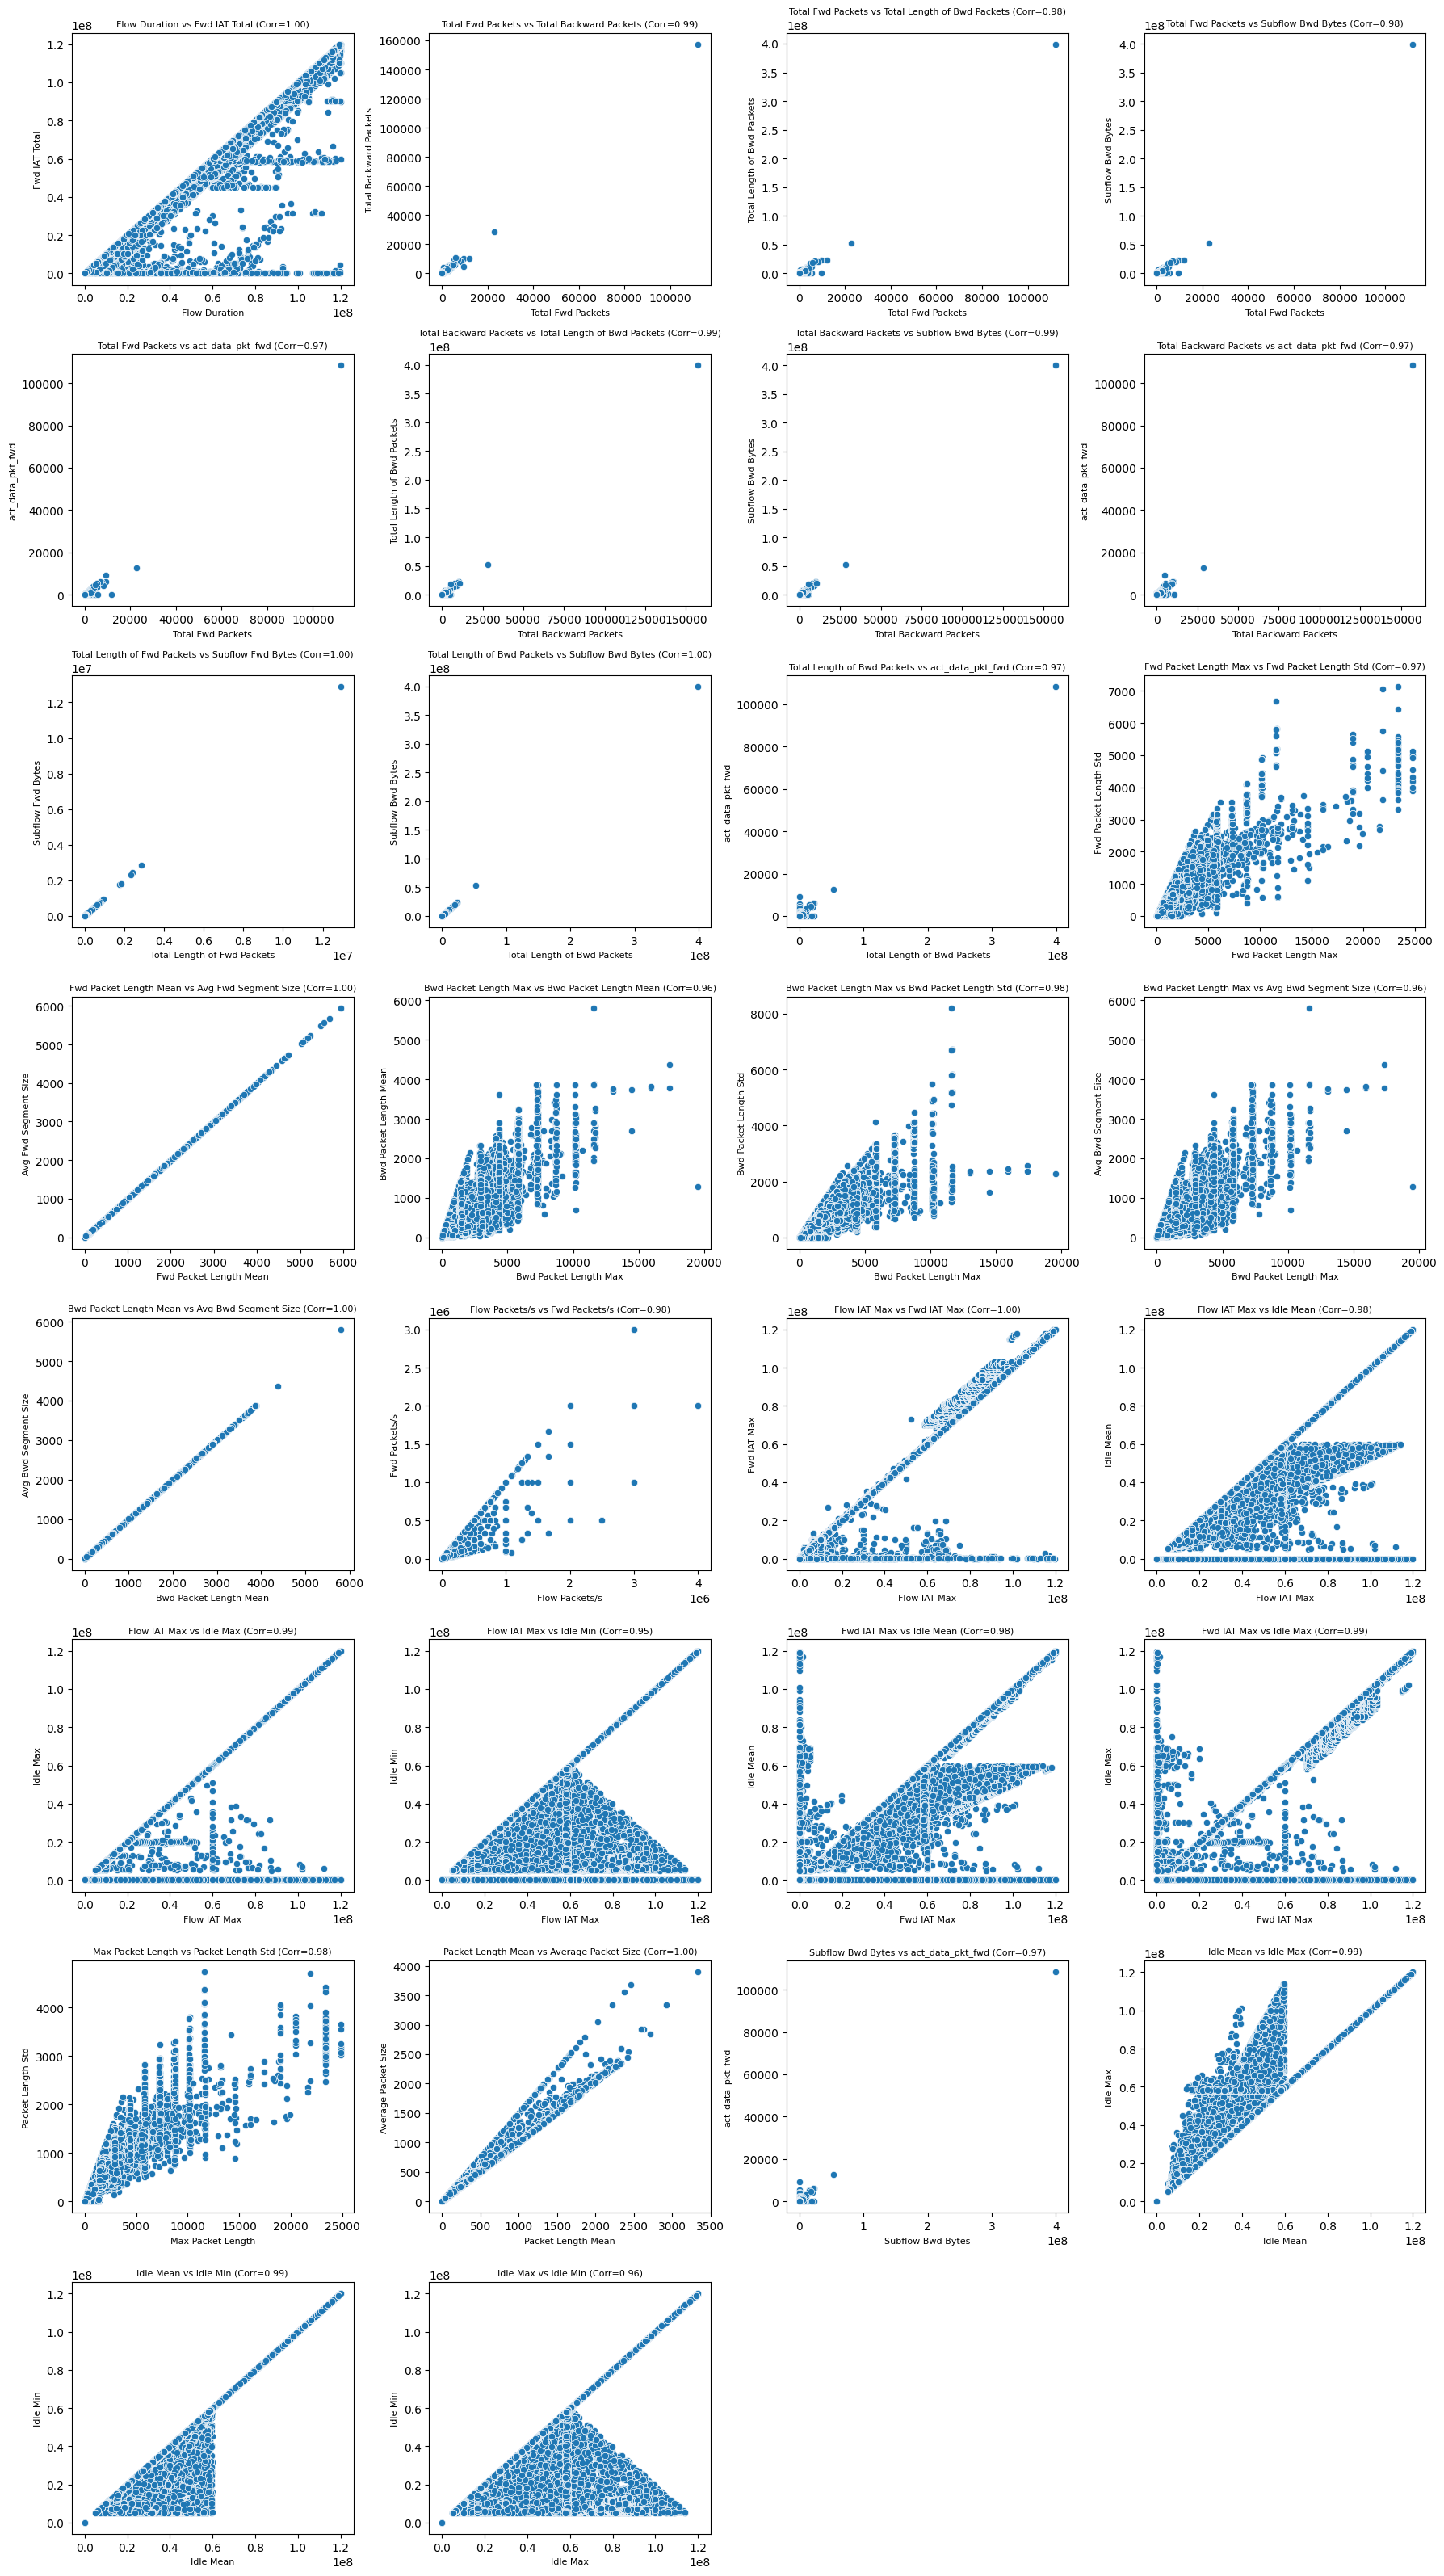

In [68]:
# Plotting the pairs with very high correlation for better visualization

n_plots = len(high_multicollinearity)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, item in enumerate(high_multicollinearity):
    feature_x = item[0]
    feature_y = item[1]
    corr_value = item[2]

    # Scatter plot
    sns.scatterplot(x=data[feature_x], y=data[feature_y], ax=axes[i])
    axes[i].set_title(f'{feature_x} vs {feature_y} (Corr={corr_value:.2f})', fontsize=8)
    axes[i].set_xlabel(feature_x, fontsize=8)
    axes[i].set_ylabel(feature_y, fontsize=8)

# Hide any unused subplots
for j in range(len(high_multicollinearity), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

By evaluating the plots, we can identify some features with perfect/near-perfect linear correlation. Removing one instance can reduce redundancy and mitigate potential issues with multicollinearity in future models

In [329]:
columns_to_drop = [
    'Fwd IAT Total',          # Correlated with Flow Duration (0.9985)
    'Total Backward Packets', # Correlated with Total Fwd Packets (0.9916)
    'Subflow Bwd Bytes',      # Correlated with Total Length of Bwd Packets (1.0)
    'act_data_pkt_fwd',       # Correlated with Total Length of Bwd Packets (0.9727)
    'Subflow Fwd Bytes',      # Correlated with Total Length of Fwd Packets (1.0)
    'Fwd Packet Length Std',  # Correlated with Fwd Packet Length Max (0.969)
    'Avg Fwd Segment Size',   # Correlated with Fwd Packet Length Mean (1.0)
    'Bwd Packet Length Std',  # Correlated with Bwd Packet Length Max (0.9831)
    'Avg Bwd Segment Size',   # Correlated with Bwd Packet Length Mean (1.0)
    'Fwd Packets/s',          # Correlated with Flow Packets/s (0.9826)
    'Fwd IAT Max',            # Correlated with Flow IAT Max (0.9981)
    'Idle Max',               # Correlated with Idle Mean (0.9902)
    'Idle Min',               # Correlated with Idle Mean (0.9901)
    'Packet Length Std',      # Correlated with Max Packet Length (0.9842)
    'Average Packet Size'     # Correlated with Packet Length Mean (0.9978)
]

# Dropping the columns from the dataframe 'data'
data = data.drop(columns=columns_to_drop)

In [330]:
# Updating the variables and checking dataset shape
numeric_features, categorical_features = get_feature_types(data)
data.shape

(2569753, 45)

## 3.4. Outliers

Outlier detection plays a crucial role in ensuring the quality and reliability of a dataset. Identifying features with significant deviations from the norm can help improve model accuracy by preventing skewed results.

<Figure size 1500x1000 with 0 Axes>

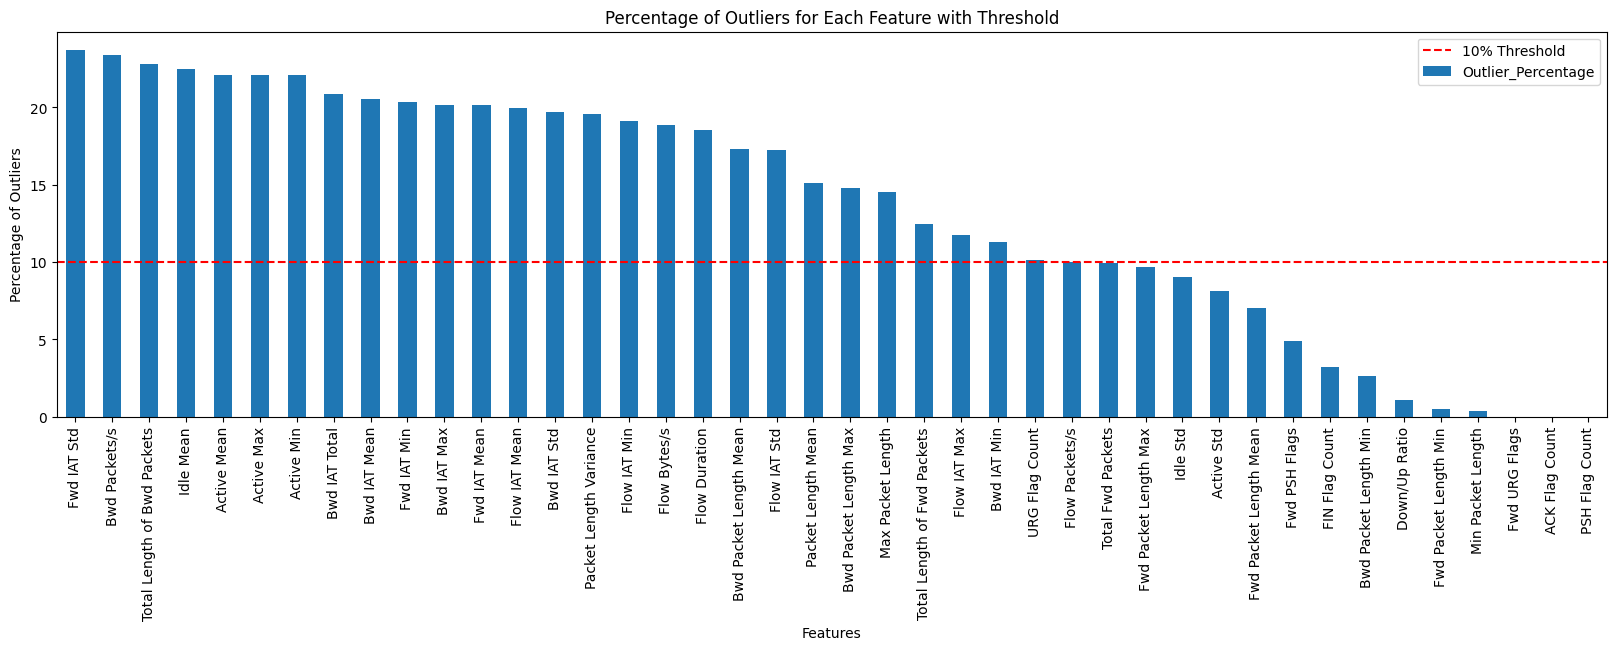

In [71]:
# Calculate outliers percentage
outlier_percentages = calculate_outliers_percentage(data[numeric_features])

# Convert to DataFrame for easier manipulation
outliers_df = pd.DataFrame.from_dict(outlier_percentages, orient='index', columns=['Outlier_Percentage'])

# Define the threshold for concern
threshold = 10

# Identify features with high percentage of outliers
high_outlier_features = outliers_df[outliers_df['Outlier_Percentage'] > threshold]

# Plot the outlier percentages and highlight features above the threshold
plt.figure(figsize=(15, 10))
outliers_df.sort_values(by='Outlier_Percentage', ascending=False).plot(kind='bar', legend=False, figsize=(20, 5))
plt.axhline(y=threshold, color='r', linestyle='--', label=f'{threshold}% Threshold')
plt.xlabel('Features')
plt.ylabel('Percentage of Outliers')
plt.title('Percentage of Outliers for Each Feature with Threshold')
plt.legend()
plt.show()

In [72]:
# Print the features with high outlier percentages
print(f"Features with outlier percentage above {threshold}%:\n")
print(high_outlier_features.sort_values('Outlier_Percentage', ascending=False))
# Cleaning up
del outliers_df

Features with outlier percentage above 10%:

                             Outlier_Percentage
Fwd IAT Std                           23.721464
Bwd Packets/s                         23.392342
Total Length of Bwd Packets           22.782831
Idle Mean                             22.458317
Active Min                            22.124430
Active Max                            22.124430
Active Mean                           22.124430
Bwd IAT Total                         20.875859
Bwd IAT Mean                          20.569216
Fwd IAT Min                           20.374691
Bwd IAT Max                           20.158004
Fwd IAT Mean                          20.127701
Flow IAT Mean                         19.991239
Bwd IAT Std                           19.697623
Packet Length Variance                19.579073
Flow IAT Min                          19.094307
Flow Bytes/s                          18.843584
Flow Duration                         18.526616
Bwd Packet Length Mean                17.28

In [73]:
# Check outliers for 'Flow Duration'
threshold = data['Flow Duration'].quantile(0.95)
outliers_df = data[data['Flow Duration'] > threshold]

print("Attack types in high outliers:")
print(outliers_df['Attack Type'].value_counts())

Attack types in high outliers:
Attack Type
BENIGN              121530
DoS Hulk              3791
DoS Slowhttptest       223
DoS slowloris          190
DoS GoldenEye          130
PortScan                14
Infiltration            10
Heartbleed               6
SSH-Patator              2
Name: count, dtype: int64


## 3.5. Data Distribution

Understanding the distribution of the data is fundamental for selecting the right preprocessing and modeling techniques. Data distribution also gives insights towards the best statistic tests to perform.

In [74]:
norm_dist = 0
not_norm_dist = 0

for col in numeric_features:

    # Perform Anderson-Darling test for normality
    result = stats.anderson(data[col], dist='norm')

    # Compare the statistic with the critical value at 5% significance level
    if result.statistic < result.critical_values[2]:  # 5% significance level
        norm_dist += 1
    else:
        not_norm_dist += 1

print(f'{norm_dist} features are normally distributed')
print(f'{not_norm_dist} features are not normally distributed - Reject null hypothesis')

0 features are normally distributed
42 features are not normally distributed - Reject null hypothesis


## 3.6. Class Imbalance

In [75]:
# Count occurrences of each attack type and convert to a DataFrame
attack_counts_df = data['Attack Type'].value_counts().reset_index()
attack_counts_df.columns = ['Attack Type', 'Number of Occurrences']

# Counting the total for each attack on both cases
total_occurrences = attack_counts_df['Number of Occurrences'].sum()

# Calculating the respective percentages
attack_counts_df['% of Total'] = ((attack_counts_df['Number of Occurrences'] / total_occurrences) * 100).round(2)

print(attack_counts_df)

                   Attack Type  Number of Occurrences  % of Total
0                       BENIGN                2092370       83.10
1                     DoS Hulk                 172688        6.86
2                         DDoS                 127995        5.08
3                     PortScan                  90694        3.60
4                DoS GoldenEye                  10281        0.41
5                  FTP-Patator                   5927        0.24
6                DoS slowloris                   5385        0.21
7             DoS Slowhttptest                   5228        0.21
8                  SSH-Patator                   3217        0.13
9                          Bot                   1948        0.08
10    Web Attack � Brute Force                   1470        0.06
11            Web Attack � XSS                    652        0.03
12                Infiltration                     35        0.00
13  Web Attack � Sql Injection                     21        0.00
14        

**Class Imbalance**

The previous analysis show a clear class imbalance, which should be taken into consideration while working with the CIC-IDS-2017, as highlighted by Panigrahi and Borah (2018).

**Observations**:
Dominance of the 'BENIGN' class/ Normal Traffic – 83.1% of the entire dataset

**Potential implications**:
* Model Bias: Models can become biased towards the majority class, leading to high accuracy but poor recall and precision for minority classes.
* Performance Metrics: In an imbalanced dataset, accuracy is often not a sufficient metric to evaluate model performance. F1-score, precision, recall, or ROC-AUC are better suited for assessing the model's ability to classify different classes effectively.

**Ideas to address the issue during DL training**:
* Class weights to penalize mistakes on minority classes
* Cross-validation with representative folds
* Partial SMOTE to help balancing the distribution
* Undersampling the majority class

In [76]:
# Cleaning up
del attack_counts_df

In [77]:
numeric_features, categorical_features = get_feature_types(data)

# 4. Feature Importance

Before conducting an analysis of feature importance, some characteristics of the dataset must be gathered. We already know it does not follow a Gaussian distribution and has a high presence of outliers. The next step is to evaluate its variance to determine the best statistical test.

In [78]:
# Applying the Levene's Test
# p-value < 0.05 suggests unequal variances among groups (rejecting the null hypothesis of equal variances)
variance_result = analyze_variance_homogeneity(data, numeric_features)

Not enough valid groups to perform Levene's test for feature: Fwd URG Flags


In [79]:
# Analysing the results
no_significant_results = True

for feature, result in variance_result.items():
    if result['p-value'] > 0.05:
        print(f"\nFeature: {feature}")
        print(f"  - Test Statistic: {result['Statistic']:.4f}")
        print(f"  - p-value: {result['p-value']:.4f}")
        print("  - Interpretation: The variances are not significantly different (fail to reject null hypothesis).")
        no_significant_results = False

# If no features had p-values > 0.05
if no_significant_results:
    print("\nNo features have p-values greater than 0.05. All features have significant differences in variance.")


No features have p-values greater than 0.05. All features have significant differences in variance.


The above evaluation (only 3 features failed to reject the null hypothesis), together with the information about distribution, invalidates the use of One-Way ANOVA. A better fit, therefore, is the Kruskal-Wallis test, which is a non-parametric alternative that does not assume equal variances and is robust to the violations of normality or homoscedasticity.

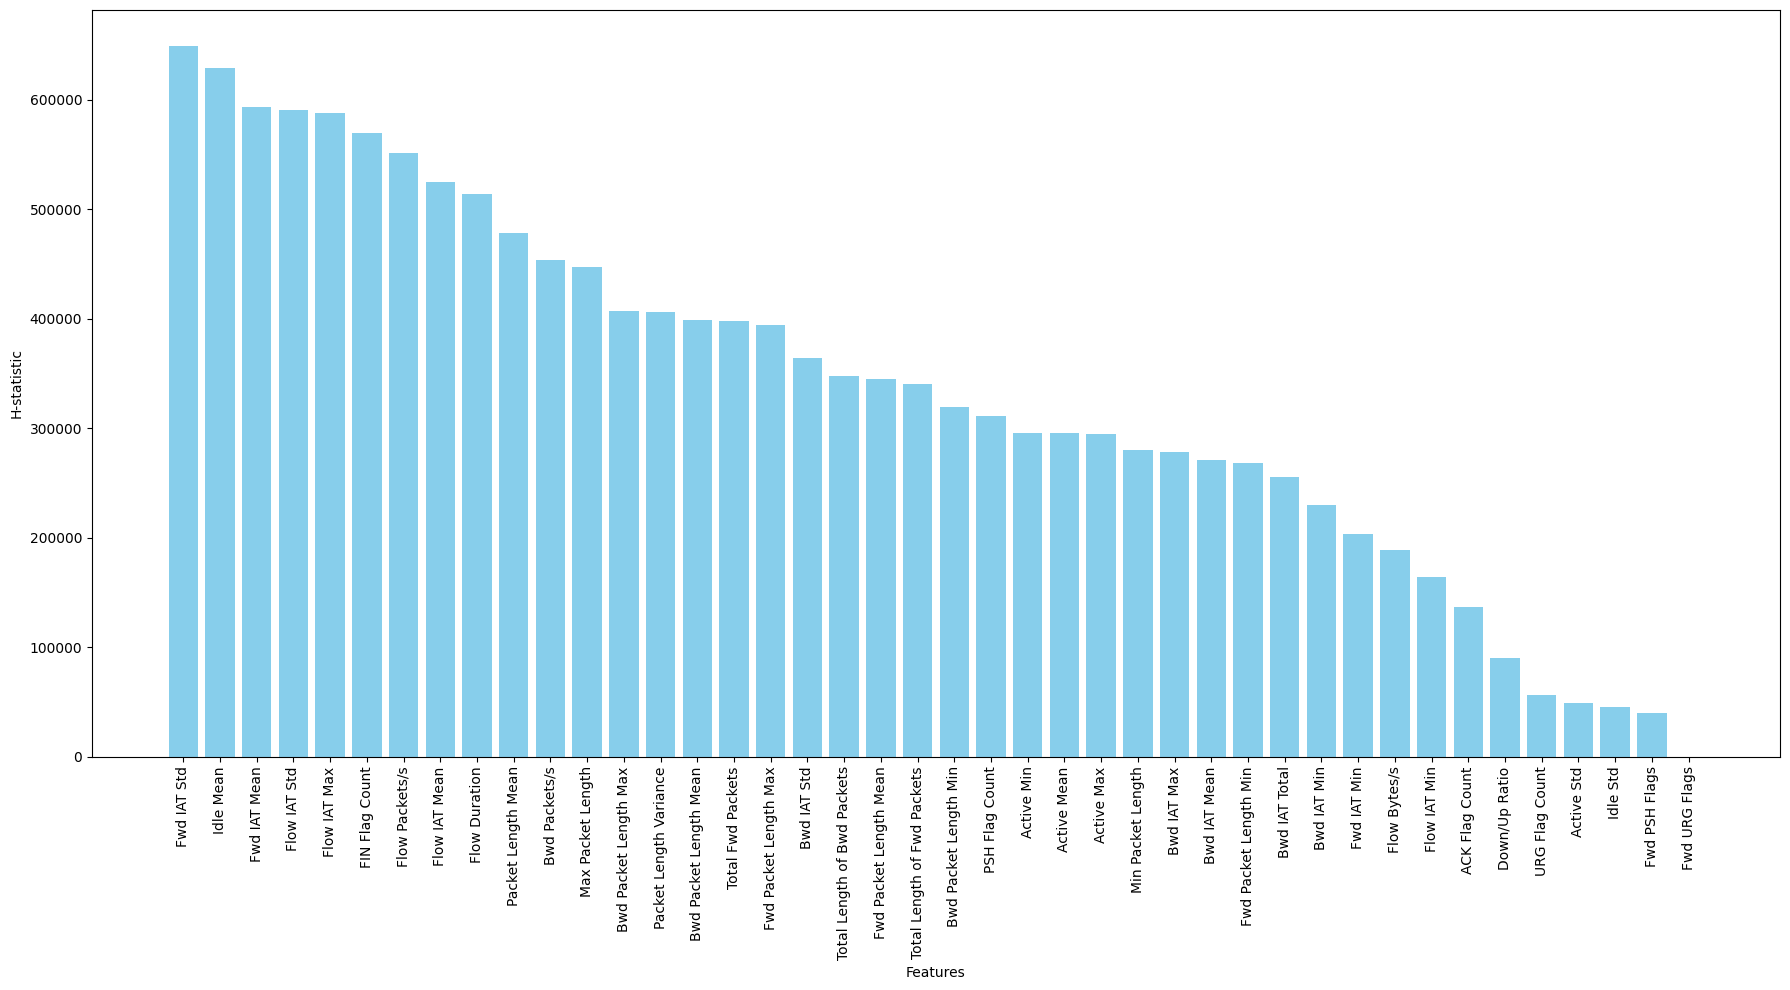

In [80]:
# Analysing feature importance using Kruskal-Wallis.
h_p_stats = analyze_feature_importance(data, numeric_features)

Now that we have the results from the Kruskal-Wallis test, we will train a Random Forest model and analyze its feature importance scores. This will provide an additional perspective on feature relevance, which we can then compare to the rankings obtained from the Kruskal-Wallis test.

C:\Users\mf\AppData\Local\Temp\ipykernel_16484\3641401600.py:33: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_subset = grouped.apply(lambda x: x.sample(n=min(len(x), samples_per_class),


Using balanced subset with 57,220 samples (6666 per class approx.)
Cross-Validation Score: 0.9723 ± 0.0006

Classification Report:



C:\Users\mf\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mf\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\mf\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

                            precision    recall  f1-score   support

                    BENIGN       0.94      0.96      0.95      2000
                       Bot       0.93      0.96      0.94       584
                      DDoS       1.00      1.00      1.00      2000
             DoS GoldenEye       1.00      1.00      1.00      2000
                  DoS Hulk       1.00      0.99      0.99      2000
          DoS Slowhttptest       1.00      0.99      1.00      1568
             DoS slowloris       0.99      1.00      0.99      1616
               FTP-Patator       1.00      1.00      1.00      1778
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.50      0.67        10
                  PortScan       1.00      1.00      1.00      2000
               SSH-Patator       0.96      0.96      0.96       965
  Web Attack � Brute Force       0.71      0.75      0.73       441
Web Attack � Sql Injection       0.00      0.00

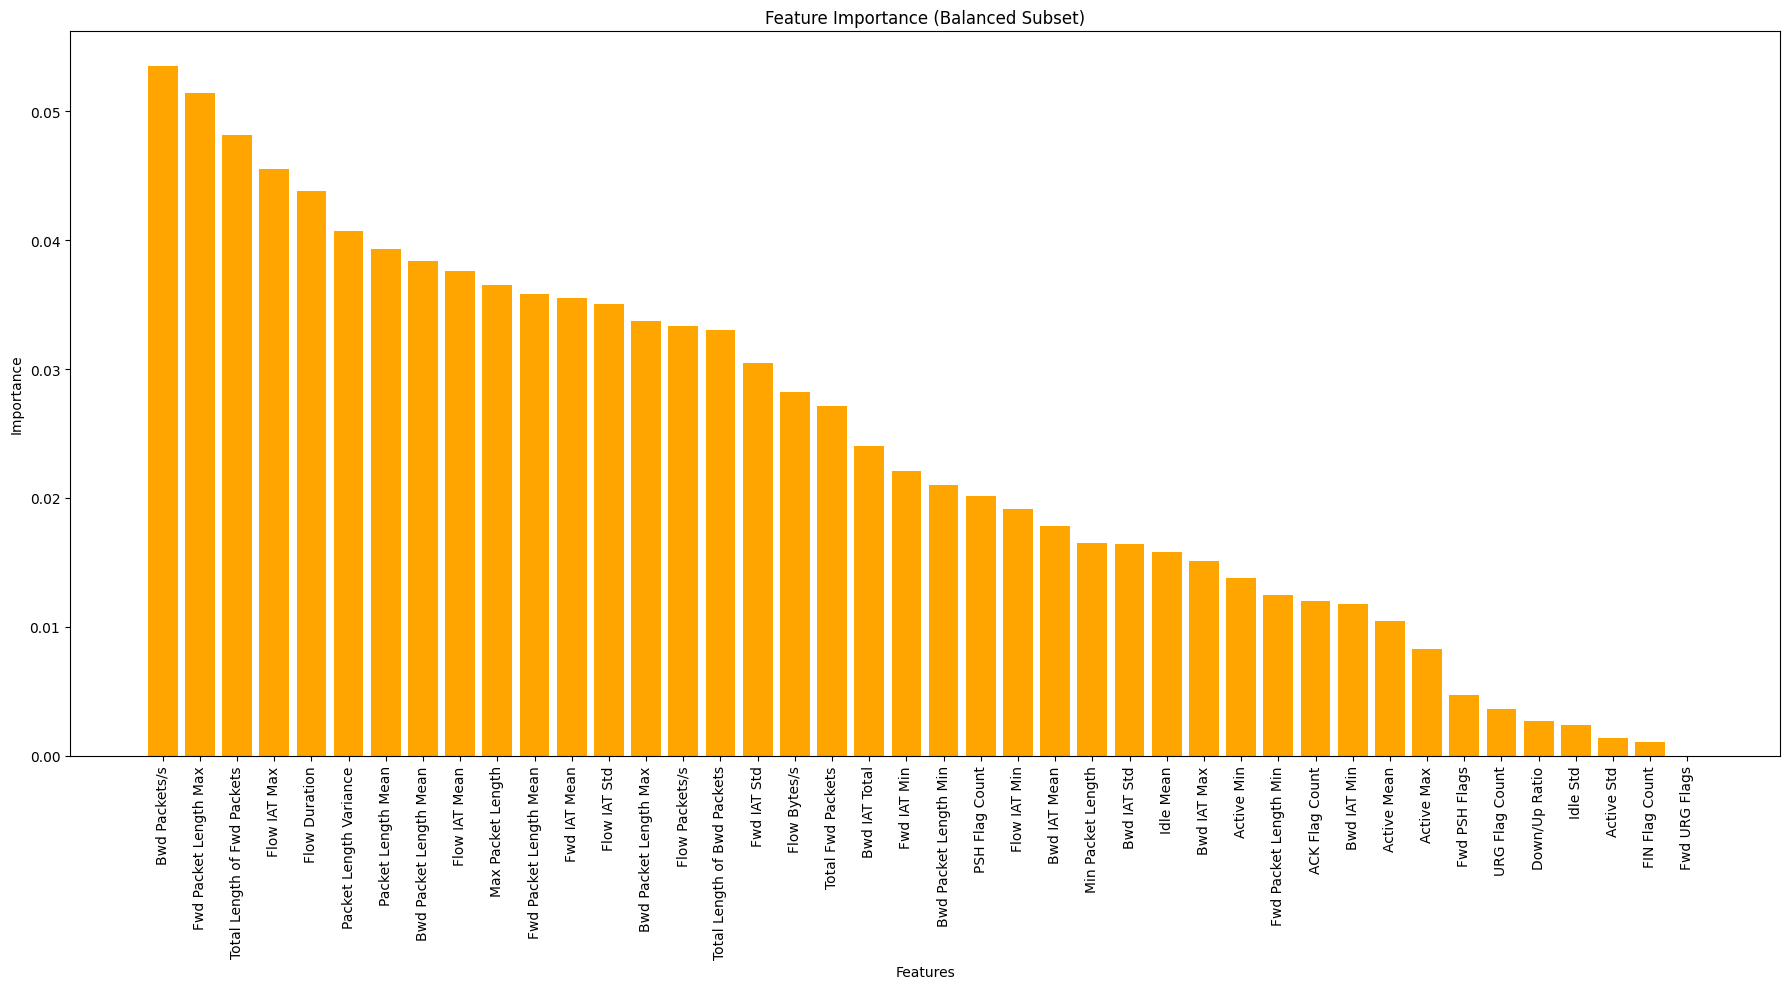

In [81]:
# # Analysing feature importance using Tree-Model
feature_importance_tree, cm, rf_labels, cv_scores = analyze_feature_importance_rf(
    data,
    numeric_features=numeric_features,
    target_col='Attack Type',
    subset_size=100000 )

Random Forests, being ensemble methods, offer a built-in mechanism for assessing feature importance. This importance is calculated based on how much each feature contributes to decreasing impurity (e.g., Gini impurity or entropy) within the decision trees of the forest. Features used higher up in the trees or in more trees of the forest for making splits are considered more important as they contribute more significantly to the model's predictive performance.

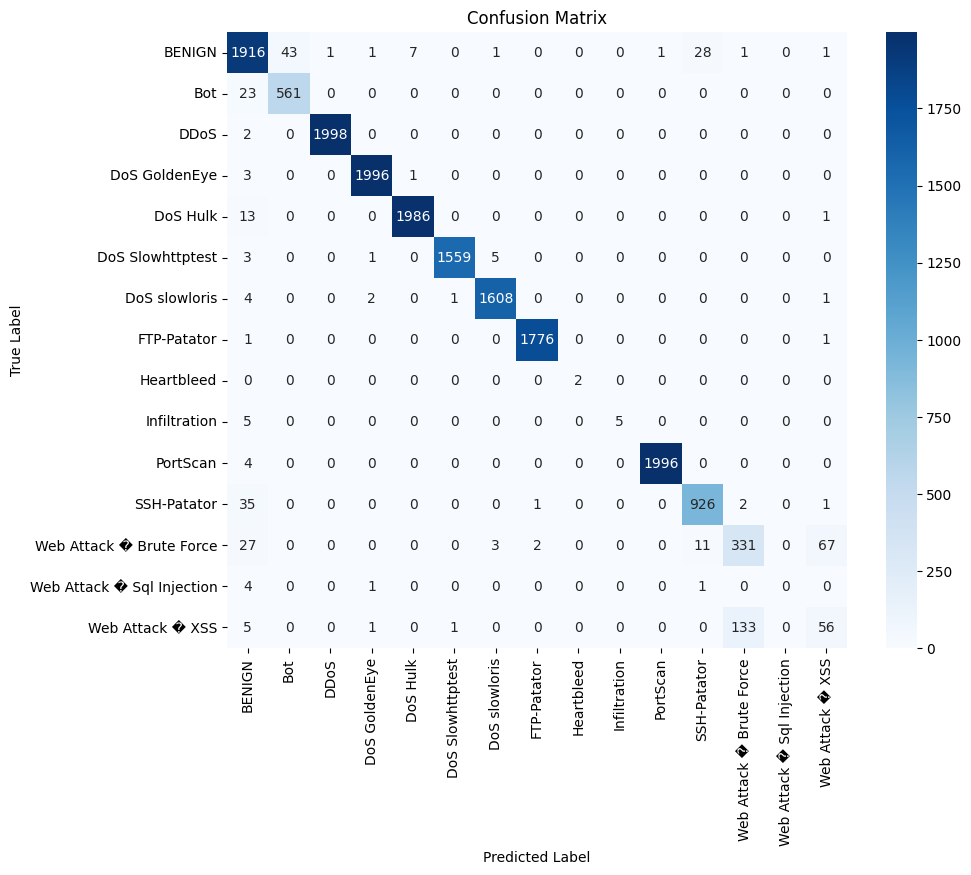

In [82]:
# Evaluating RF performance based on selected features
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8)) # Adjust figure size as needed
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf_labels, yticklabels=rf_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

After evaluating the Random Forest model's performance, we observe an overall positive result, indicating its suitability for feature importance analysis. However, the confusion matrix and the classification report reveal a notable weakness in classifying Bot attacks, with roughly 1/4 of these instances being misclassified as normal traffic (which is not surprising, considering this is a minority class). This misclassification highlights a potential area for improvement in our final intrusion detection model, which could be explored by considering more sophisticated bot detection methods, specialized feature engineering, and data balancing techniques. Despite this limitation, the overall performance justifies using the Random Forest's feature importance scores as a valuable reference for comparison with the Kruskal-Wallis H-statistic in our subsequent feature selection process.

In [83]:
# Preparing the df for comparison
h_p_stats.reset_index(inplace = True)
h_p_stats.rename(columns = {'index':'Feature'}, inplace = True)

# Sorting the new df for easier visualization
comparison_tb = feature_importance_tree.merge(h_p_stats, on = 'Feature', how = 'left')
comparison_tb_sorted = comparison_tb.sort_values(by='Importance', ascending=False)
comparison_tb_sorted

,Feature,Importance,H-statistic,p-value
0,Bwd Packets/s,0.053545,453331.689710,0.000000
1,Fwd Packet Length Max,0.051449,394482.606869,0.000000
2,Total Length of Fwd Packets,0.048189,339910.907152,0.000000
3,Flow IAT Max,0.045515,587315.381968,0.000000
4,Flow Duration,0.043795,514047.224704,0.000000
5,Packet Length Variance,0.040758,406438.063742,0.000000
6,Packet Length Mean,0.039317,477830.683361,0.000000
7,Bwd Packet Length Mean,0.038394,398630.685479,0.000000
8,Flow IAT Mean,0.037635,525070.607027,0.000000
9,Max Packet Length,0.036565,447449.270035,0.000000


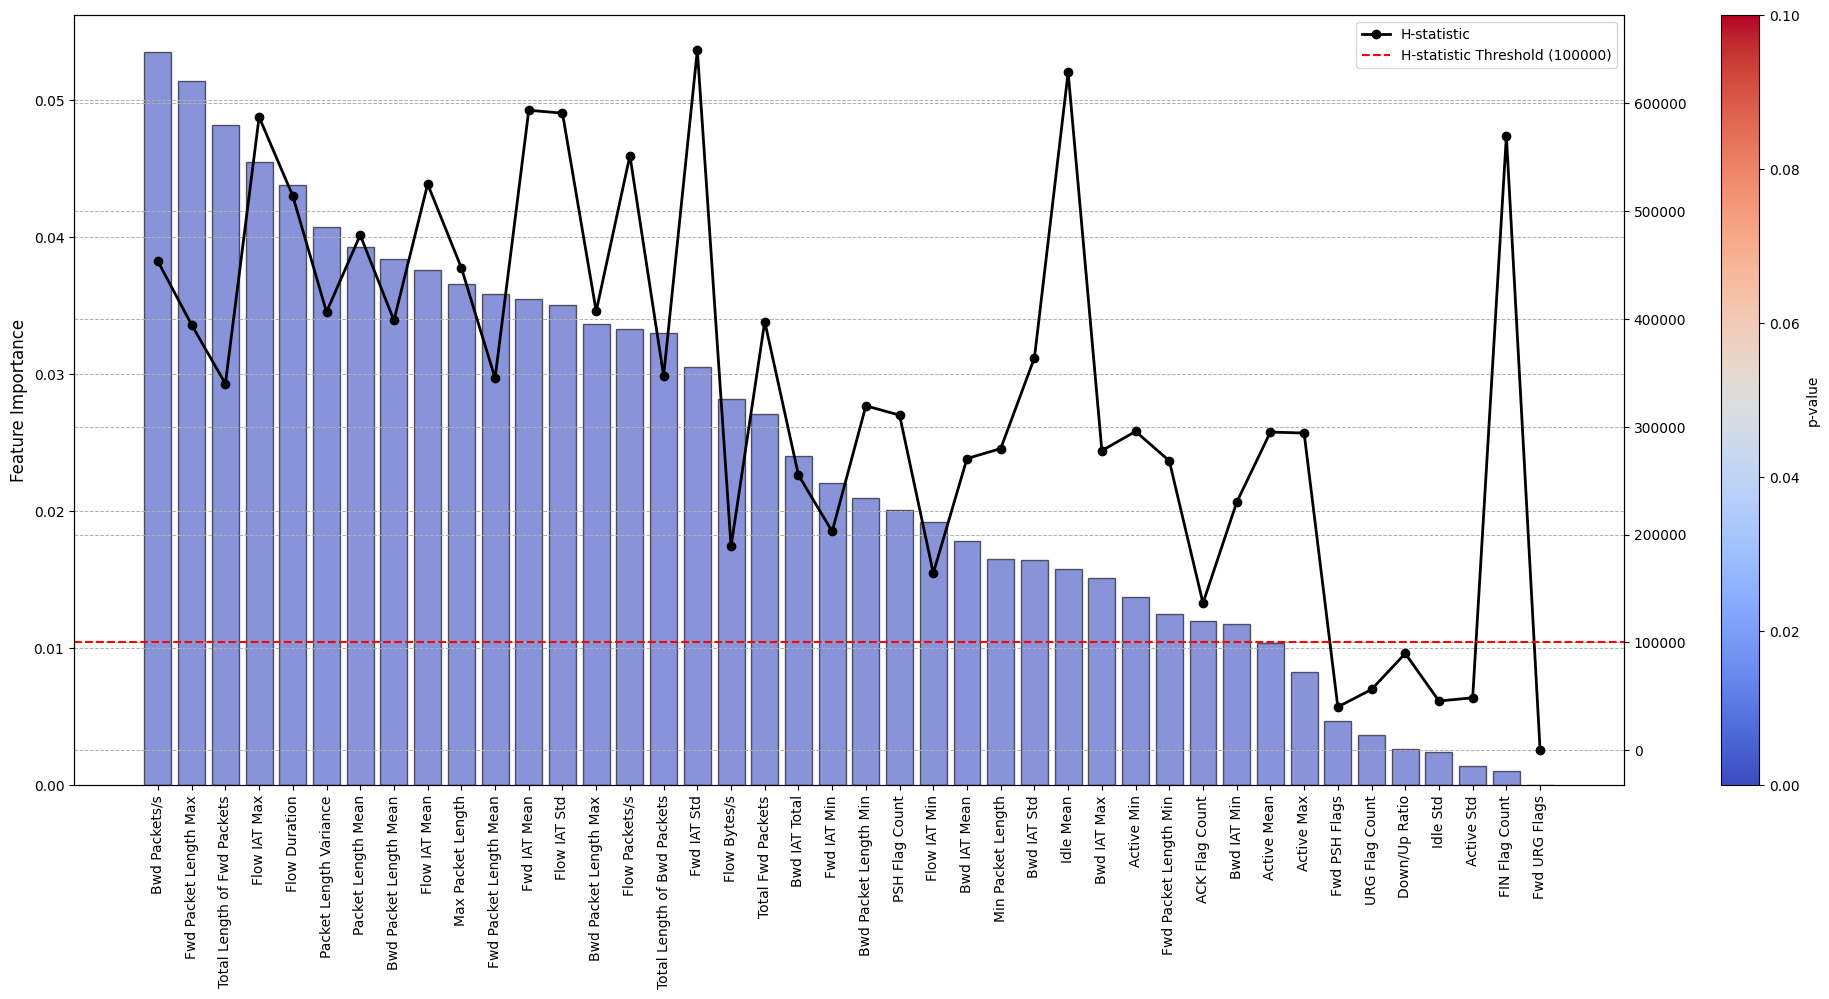

In [84]:
# Create figure and axis
plt.figure(figsize=(25, 10))

# Create a color map based on p-value
colors = sns.color_palette("coolwarm", as_cmap=True)

# Create twin axes for different scales
ax1 = plt.gca()
ax2 = ax1.twinx()

# Plot bars for importance
bars = ax1.bar(comparison_tb_sorted['Feature'],
                comparison_tb_sorted['Importance'],
                alpha=0.6,
                color=[colors(0 + (value)) for value in comparison_tb_sorted['p-value']], edgecolor='black')

# Plot line for H-statistic
line = ax2.plot(comparison_tb_sorted['Feature'],
                 comparison_tb_sorted['H-statistic'],
                 color='black',
                 linewidth=2,
                 label='H-statistic',
                 marker='o')

# Add a horizontal threshold line
threshold = 100000
ax2.axhline(y=threshold, color='red', linestyle='--', label=f'H-statistic Threshold ({threshold})')
ax2.legend()

# Customize primary y-axis (Importance)
ax1.set_ylabel('Feature Importance', fontsize=12, color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Set x-ticks and labels
ax1.set_xticks(range(len(comparison_tb_sorted['Feature'])))
ax1.set_xticklabels(comparison_tb_sorted['Feature'], rotation=90, ha='center', fontsize=10)

# Add title
# plt.title('Feature Importance from Random Forest with H-statistics and p-values',
#           fontsize=14, pad=20)

# Add colorbar for p-values
sm = plt.cm.ScalarMappable(cmap=colors, norm=plt.Normalize(vmin=comparison_tb_sorted['p-value'].min(), vmax=0.1))
cbar = plt.colorbar(sm, ax=ax1, orientation='vertical')
cbar.set_label('p-value', fontsize=10)

# Add gridlines for readability
ax1.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7)
ax2.grid(True, which='both', axis='y', linestyle='--', linewidth=0.7)

plt.show()

The plot illustrates that while some features selected by the Random Forest (RF) have lower H-statistics, the most significant features are found within the range where the highest H-statistic values are concentrated. The most interesting information, however, lies on the right tail, where there is a convergence on the lowest priority and near-zero H-statistic relevance. Based on these results, the least important features will be removed from the dataset, which helps with:

 * Improving Model Efficiency: Training with fewer features reduces computational cost (time and memory).
 * Reducing Noise: Removing irrelevant features can sometimes improve model performance by reducing noise and preventing overfitting.
 * Simplifying Interpretation: Models with fewer features are often easier to interpret and explain.

In [331]:
# Removing statiscally irrelavant features from the dataset
cols_to_remove = ['Fwd URG Flags']
data.drop(columns=cols_to_remove, inplace=True)

In [332]:
data.shape[1]

44

# 5. Target Encoding

In [333]:
group_mapping = {
    'BENIGN': 'Normal',
    'DoS Hulk': 'Malicious',
    'DDoS': 'Malicious',
    'PortScan': 'Malicious',
    'DoS GoldenEye': 'Malicious',
    'FTP-Patator': 'Malicious',
    'DoS slowloris': 'Malicious',
    'DoS Slowhttptest': 'Malicious',
    'SSH-Patator': 'Malicious',
    'Bot': 'Malicious',
    'Web Attack � Brute Force': 'Malicious',
    'Web Attack � XSS': 'Malicious',
    'Infiltration': 'Malicious',
    'Web Attack � Sql Injection': 'Malicious',
    'Heartbleed': 'Malicious'
}

# Map to new group column
data['Attack Type'] = data['Attack Type'].map(group_mapping)

In [334]:
data['Attack Type'] = data['Attack Type'].map({'Normal': 0, 'Malicious': 1})

# 6. Splitting data (model training / realtime stream simulation)

In [351]:
X = data.drop(columns= "Attack Type")
y = data["Attack Type"]

In [ ]:
train_X, live_X, train_y, live_y = train_test_split(
    X, y,
    test_size=0.50,           
    stratify=y,               
    random_state=42
)

train_df = pd.concat([train_X, train_y], axis=1)
live_df  = pd.concat([live_X, live_y], axis=1)
live_df = live_df.drop(columns = ["Attack Type"])

train_df.to_csv("train_data.csv", index=False)
live_df.to_csv("live_simulation.csv", index=False)

TypeError: cannot concatenate object of type '<class 'numpy.ndarray'>'; only Series and DataFrame objs are valid

In [234]:
del X, y, train_X, live_X, train_y, live_y, live_df